In [ ]:
# must pip install required packages
!pip install pygments python-Levenshtein javalang

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.3 MB/s eta 0:00:00


In [ ]:
#Peace Samuel, 121376141

import os
#import ast
import javalang
import re
import hashlib
from pygments import lex
from pygments.lexers import get_lexer_by_name
from pygments.token import Token
from collections import Counter
import math
import Levenshtein
import matplotlib.pyplot as plt
from itertools import combinations
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

## Plagiarism Detection Algorithm: MOSS

This class implements the steps in the MOSS inspired plagiarism detection algorithm

In [ ]:
class MOSS:
    def __init__(self, code, language, n=15, window_size=10):
        self.og_code = code
        self.language = language
        #self.normalised_text = ""
        self.tokens = []
        self.normalised_tokens = []
        self.k_grams = []
        self.hashes = []
        self.window_size = window_size
        self.n = n
        self.fingerprints = []

# def normalise_text(self):
    #     """
    #     Function to remove any irrelevant features in the text like whitespace, and punctuation
    #     """
    #     #set all text to lowercase and replace remove whitespace
    #     self.normalised_text = re.sub(r'\W+', '', self.og_text.lower())
    #     print("Cleaned text with irrelevant features removed:" + "\n" + self.normalised_text)
    #     return self.normalised_text

    def normalize_code(self):
      """
      Function that uses Pygments to normalize code
      Replaces variable names with T
      Replaces function names with F
      """
      lexer = get_lexer_by_name(self.language)
      tokens = lex(self.og_code, lexer)

      variable_map = {}
      function_map = {}
      normalized_tokens = []

      for token_type, token_value in tokens:
        if token_type in Token.Comment:
          continue  #skip any comments
        elif token_type in Token.Keyword:
          normalized_tokens.append(token_value)#no change for keywords
        elif token_type in Token.Name.Function:
          if token_value not in function_map: #replace function names
            function_map[token_value] = "F"
          normalized_tokens.append(function_map[token_value])
        elif token_type in Token.Name: #replace variable names
          if token_value not in variable_map:
            variable_map[token_value] = "T"
          normalized_tokens.append(variable_map[token_value])
        else:
          normalized_tokens.append(token_value) #keep everything else

      self.og_code = " ".join(normalized_tokens)
      #print(self.og_code)

    def tokenize_code(self):
        """
        Function creates tokens from the code, using the Pygments (removes irrelevant elements)
        """
        lexer = get_lexer_by_name(self.language) #language in this case is java
        raw_tokens = lex(self.og_code, lexer)

        #remove whitespace and comments
        self.tokens = [token_value for token_type, token_value in raw_tokens
                       if token_type not in [Token.Comment, Token.Text.Whitespace]]

        #normalise tokens, covert to lowercase
        self.normalised_tokens = [token.lower() if token.isidentifier() else token for token in self.tokens]
        # print("Tokenized and normalised code: " +"\n"+" ".join(self.normalised_tokens))
        return self.normalised_tokens

    def generate_kgrams(self):
        """
        Function that generates k-grams from the normalised code
        """
        #self.k_grams = [self.normalised_text[i:i + self.n] for i in range(len(self.normalised_text)-self.n +1)]
        self.k_grams = [" ".join(self.normalised_tokens[i:i + self.n])
                        for i in range(len(self.normalised_tokens) - self.n + 1)]

        # print("\n Sequence of (k-grams)5-grams: \n" + " " .join(self.k_grams))
        return self.k_grams

    def hash_kgrams(self):
        """
        Function that hashes k-grams
        """
        self.hashes = [
        int(hashlib.sha1(gram.encode('utf-8')).hexdigest(), 16) % 100
        for gram in self.k_grams
        ]
        #self.hashes = [abs(hash(gram)) % 100 for gram in self.k_grams] #use python hash function
        # print("\n Sequence of hashes of the (k-grams)5 grams: \n"+ " ".join(map(str, self.hashes)))
        return self.hashes

    def create_windows(self):
        """
        Function that creates windows of a fixed sized on the hashed k-grams
        """
        windows = [self.hashes[i:i + self.window_size] for i in range(len(self.hashes) -  self.window_size+1)]
        # print("\n Windows of hashes of length 4:")
        # for window in windows:
        #      print(tuple(window))
        return windows

    def winnowing(self):
        """
        Function that uses the winnowing method for fingerprinting (select hash windows based on the minimum has in each window)
        """
        windows = self.create_windows() # call the function to create the windows
        last_pos = None
        for i, window in enumerate(windows):
            min_hash = min(window)
            min_index = i + window.index(min_hash)
            if last_pos is None or self.fingerprints[-1][0] != min_hash:
                self.fingerprints.append((min_hash, min_index))
                last_pos = min_index

        # print("\n Fingerprints selected by winnowing:")
        # print(" ".join(f"[{h},{p}]" for h, p in self.fingerprints))

        #print("\n Fingerprints selected by winnowing (hash, position):"+ " ".join(f"[{h},{p}]" for h, p in self.fingerprints))
        return self.fingerprints


    def run(self):
        """
        Function that runs all steps
        """
        #print(f"Original code:\n{self.og_code}")
        self.normalize_code()
        self.tokenize_code()
        self.generate_kgrams()
        self.hash_kgrams()
        self.winnowing()
        #return self.fingerprints #explicitly returns the fingerprints for comparison


In [ ]:
code_sample = """
public class Welcome {
    public static void main(String[] args) {
        for (int i = 0; i < 5; i++) {
            System.out.println("Welcome to Java");
        }
    }
}
"""

## Create Comparator classes

These various comparator classes will be used alongside the plagiarism detection algorithm to return the degree of similarity between two source code.
Three different approaches will be implemented.

### Comparator: Jaccard Similarity

In [ ]:
class Comparator:
    def __init__(self, moss_instance_1, moss_instance_2):
        """
            Initializes the Jaccard Similarity Comparator with two MOSS instances
            This works by computing the intersection of tokens between the two sets and dividing by the total number of tokens
        """
        self.moss1 = moss_instance_1
        self.moss2 = moss_instance_2

    def compare(self):
        """
        Function compares the fingerprints of two MOSS objects and calculates a similarity score
        """
        #extract fingerprints
        fingerprints1 = self.moss1.fingerprints
        fingerprints2 = self.moss2.fingerprints

        #convert fingerprints into sets of hashes
        set1 = set()
        for fp in fingerprints1:
            set1.add(fp[0])

        set2 = set()
        for fp in fingerprints2:
            set2.add(fp[0])

        #find common hashes
        common_fingerprints = set1.intersection(set2)

        #calculate similarity score
        total_fingerprints = len(set1.union(set2))
        similarity_score = len(common_fingerprints) / total_fingerprints * 100 #if total_fingerprints > 0 else 0

        #print results
        #print(f"Jaccard Similarity score: {similarity_score:.2f}%")

        return similarity_score, common_fingerprints


    def check(self):
        """
        Function to display the original code, common fingerprints, and corresponding tokens.
        """
        similarity_score, common_fingerprints = self.compare()

        #print original code, after normalisation
        print("\nOriginal Code 1:\n", self.moss1.og_code)
        print("\nOriginal Code 2:\n", self.moss2.og_code)

        #print common fingerprints and their corresponding tokens
        print("\nCommon Fingerprints and Corresponding Tokens:")

        for fp in common_fingerprints:
            pos1 = [pos for hash_val, pos in self.moss1.fingerprints if hash_val == fp]
            pos2 = [pos for hash_val, pos in self.moss2.fingerprints if hash_val == fp]

            #extract tokens corresponding to these positions
            tokens1 = [self.moss1.normalised_tokens[pos] for pos in pos1 if pos < len(self.moss1.normalised_tokens)]
            tokens2 = [self.moss2.normalised_tokens[pos] for pos in pos2 if pos < len(self.moss2.normalised_tokens)]

            print(f"Fingerprint: {fp}")
            print(f"Code 1 Tokens: {tokens1}")
            print(f"Code 2 Tokens: {tokens2}\n")

### Comparator: Cosine Similarity

In [ ]:
class Comparator2:
    def __init__(self, moss_instance_1, moss_instance_2):
        """
        Initializes the Cosine Similarity Comparator with two MOSS instances
        """
        self.moss1 = moss_instance_1
        self.moss2 = moss_instance_2

    def calculate_cosine_similarity(self, fingerprints1, fingerprints2):
        """
        Calculates the cosine similarity between two sets of fingerprints
        """
        #count the occurrences of each fingerprint (to form the vector)
        vector1 = Counter(fingerprints1)
        vector2 = Counter(fingerprints2)

        #get the unique set of all fingerprints
        all_fingerprints = set(vector1.keys()).union(set(vector2.keys()))

        #compute the dot product and magnitude of vectors
        dot_product = sum(vector1[fp] * vector2[fp] for fp in all_fingerprints)
        magnitude1 = math.sqrt(sum(count ** 2 for count in vector1.values()))
        magnitude2 = math.sqrt(sum(count ** 2 for count in vector2.values()))

        #avoid division by zero
        if magnitude1 == 0 or magnitude2 == 0:
            return 0.0

        #calculate cosine similarity
        return (dot_product / (magnitude1 * magnitude2)) * 100

    def compare(self):
        """
        Compares the fingerprints of the two MOSS instances to calculate similarity using Cosine Similarity
        """
        #loop through the fingerprints and append the first element
        fingerprints1 = []
        fingerprints2 = []
        for fp in self.moss1.fingerprints:
            fingerprints1.append(fp[0])

        for fp in self.moss2.fingerprints:
            fingerprints2.append(fp[0])


        #calculate cosine similarity
        similarity_score = self.calculate_cosine_similarity(fingerprints1, fingerprints2)
        #print(f"Cosine Similarity Score: {similarity_score:.2f}")
        return similarity_score, fingerprints1, fingerprints2

    def check(self):
        """
        Function to display original code, tokens, fingerprints, and similarity details.
        """
        #extract fingerprint hashes
        similarity_score, fingerprints1, fingerprints2 = self.compare()

        #find common tokens
        common_tokens = set(self.moss1.tokens).intersection(set(self.moss2.tokens))

        #print original code
        print("\nOriginal Code 1:\n", self.moss1.og_code)
        print("\nOriginal Code 2:\n", self.moss2.og_code)

        #print extracted tokens
        print("\nTokens of Code 1:\n", " ".join(self.moss1.tokens))
        print("\nTokens of Code 2:\n", " ".join(self.moss2.tokens))

        #print common tokens
        print("\nCommon Tokens:\n", " ".join(common_tokens) if common_tokens else "No common tokens.")

        #print fingerprints
        print("\nFingerprints of Code 1:\n", " ".join(map(str, fingerprints1)))
        print("\nFingerprints of Code 2:\n", " ".join(map(str, fingerprints2)))

### Comparator: Levenshtein Similarity

In [ ]:
class Comparator3:
    def __init__(self, moss_instance_1, moss_instance_2):
        """
        Initializes the Levenshtein Comparator with two MOSS instances
        """
        self.moss1 = moss_instance_1
        self.moss2 = moss_instance_2

    def get_fingerprint_string(self, fingerprints):
        """
        Converts a list of fingerprints into a single string for comparison
        """
        fingerprint_strings = []
        for fp in fingerprints:
            fingerprint_strings.append(str(fp[0]))
        return " ".join(fingerprint_strings)

    def calculate_levenshtein_similarity(self):
        """
        Calculates the Levenshtein similarity based on the MOSS fingerprints
        """
        #run MOSS to generate fingerprints
        fingerprints1 = self.moss1.fingerprints
        fingerprints2 = self.moss2.fingerprints

        #convert fingerprints to strings
        fingerprint_str1 = self.get_fingerprint_string(fingerprints1)
        fingerprint_str2 = self.get_fingerprint_string(fingerprints2)

        #calculate Levenshtein distance
        distance = Levenshtein.distance(fingerprint_str1, fingerprint_str2)
        max_length = max(len(fingerprint_str1), len(fingerprint_str2))

        #normalize similarity to range [0, 100]
        similarity = (1 - (distance / max_length)) * 100 if max_length > 0 else 100.0
        return similarity, fingerprint_str1, fingerprint_str2

    def compare(self):
        """
        Compares the two MOSS instances using Levenshtein similarity
        """
        similarity_score = self.calculate_levenshtein_similarity()
        #print(f"Levenshtein Similarity Score: {similarity_score:.2f}")
        return similarity_score

    def check(self):
        """
        Function to display original code, fingerprints, and similarity details.
        """
        similarity_score, fingerprint_str1, fingerprint_str2 = self.calculate_levenshtein_similarity()

        #find common tokens
        common_tokens = set(self.moss1.tokens).intersection(set(self.moss2.tokens))

        #print original code
        print("\nOriginal Code 1:\n", self.moss1.og_code)
        print("\nOriginal Code 2:\n", self.moss2.og_code)

        #print extracted tokens
        print("\nTokens of Code 1:\n", " ".join(self.moss1.tokens))
        print("\nTokens of Code 2:\n", " ".join(self.moss2.tokens))

        #print common tokens
        print("\nCommon Tokens:\n", " ".join(common_tokens) if common_tokens else "No common tokens.")

        #print fingerprints
        print("\nFingerprints of Code 1:\n", fingerprint_str1)
        print("\nFingerprints of Code 2:\n", fingerprint_str2)

### Run examples, Testing functionality:

In [ ]:
#code samples
code1 = """
import java.util.Scanner;

public class T2 {
	public static void main(String[] args) {
		Scanner input = new Scanner(System.in);

		// Enter radius of the cylinder
		System.out.print("Enter the radius and length of a cylinder: ");
		double radius = input.nextDouble();
		double length = input.nextDouble();

		double area = radius * radius * 3.14159;
		double volume = area * length;

		System.out.println("The area is " + area);
		System.out.println("The volume of the cylinder is " + volume);
	}

}
"""

code2 = """
import java.util.Scanner;
public class T02
{
   public static void main(String[] args)
   {
      Scanner sc = new Scanner(System.in);
      System.out.print("Enter the radius and length of a cylinder: ");
      String radlen= sc.nextLine();
      String[] splited = radlen.split("\\s+");
      float rad = Float.parseFloat(splited[0]);
      float len = Float.parseFloat(splited[1]);
      System.out.println("The area is "+Math.round(rad*rad*3.14159*10000.0)/10000.0);
      System.out.println("The volume is "+Math.round(rad*rad*3.14159*len*10.0)/10.0);

   }
}
"""

In [ ]:
#create MOSS objects
moss1 = MOSS(code1, "java")
moss2 = MOSS(code2, "java")

#run the MOSS algorithm
moss1.run()
moss2.run()

In [ ]:
#Jaccard Similarity
#compare the two objects
comparator = Comparator(moss1, moss2)
similarity_score, common_fingerprints = comparator.compare()
print("Jaccard Similarity Score: " + str(similarity_score)+"%")

Jaccard Similarity Score: 23.91304347826087%


In [ ]:
comparator.check()


Original Code 1:
 import   T ; 
 
 public   class   T   { 
 	 public   static   void   F ( T [ ]   T )   { 
 		 T   T   =   new   T ( T . T ) ; 
 
 		 
 		 T . T . T ( " Enter the radius and length of a cylinder:  " ) ; 
 		 double   T   =   T . T ( ) ; 
 		 double   T   =   T . T ( ) ; 
 
 		 double   T   =   T   *   T   *   3.14159 ; 
 		 double   T   =   T   *   T ; 
 
 		 T . T . T ( " The area is  "   +   T ) ; 
 		 T . T . T ( " The volume of the cylinder is  "   +   T ) ; 
 	 } 
 
 } 


Original Code 2:
 import   T ; 
 public   class   T 
 { 
     public   static   void   F ( T [ ]   T ) 
     { 
        T   T   =   new   T ( T . T ) ; 
        T . T . T ( " Enter the radius and length of a cylinder:  " ) ; 
        T   T =   T . T ( ) ; 
        T [ ]   T   =   T . T ( " \ s+ " ) ; 
        float   T   =   T . T ( T [ 0 ] ) ; 
        float   T   =   T . T ( T [ 1 ] ) ; 
        T . T . T ( " The area is  " + T . T ( T * T * 3.14159 * 10000.0 ) / 10000.0 ) ; 
        T . T . T

In [ ]:
# Cosine Similarity
# Create the comparator and compare the two codes
comparator = Comparator2(moss1, moss2)
similarity_score, fingerprint1, fingerprint2= comparator.compare()
print("Cosine Similarity Score: " + str(similarity_score)+"%")

Cosine Similarity Score: 28.1271975231506%


In [ ]:
comparator.check()


Original Code 1:
 import   T ; 
 
 public   class   T   { 
 	 public   static   void   F ( T [ ]   T )   { 
 		 T   T   =   new   T ( T . T ) ; 
 
 		 
 		 T . T . T ( " Enter the radius and length of a cylinder:  " ) ; 
 		 double   T   =   T . T ( ) ; 
 		 double   T   =   T . T ( ) ; 
 
 		 double   T   =   T   *   T   *   3.14159 ; 
 		 double   T   =   T   *   T ; 
 
 		 T . T . T ( " The area is  "   +   T ) ; 
 		 T . T . T ( " The volume of the cylinder is  "   +   T ) ; 
 	 } 
 
 } 


Original Code 2:
 import   T ; 
 public   class   T 
 { 
     public   static   void   F ( T [ ]   T ) 
     { 
        T   T   =   new   T ( T . T ) ; 
        T . T . T ( " Enter the radius and length of a cylinder:  " ) ; 
        T   T =   T . T ( ) ; 
        T [ ]   T   =   T . T ( " \ s+ " ) ; 
        float   T   =   T . T ( T [ 0 ] ) ; 
        float   T   =   T . T ( T [ 1 ] ) ; 
        T . T . T ( " The area is  " + T . T ( T * T * 3.14159 * 10000.0 ) / 10000.0 ) ; 
        T . T . T

In [ ]:
#Levenshtein Distance import 'python-levenshtein' library
# Compare using LevenshteinComparator
comparator = Comparator3(moss1, moss2)
similarity_score, fingerprint1, fingerprint2 = comparator.compare()
print("Levenshtein Distance Score: " + str(similarity_score)+"%")

Levenshtein Distance Score: 52.800000000000004%


In [ ]:
comparator.check()


Original Code 1:
 import   T ; 
 
 public   class   T   { 
 	 public   static   void   F ( T [ ]   T )   { 
 		 T   T   =   new   T ( T . T ) ; 
 
 		 
 		 T . T . T ( " Enter the radius and length of a cylinder:  " ) ; 
 		 double   T   =   T . T ( ) ; 
 		 double   T   =   T . T ( ) ; 
 
 		 double   T   =   T   *   T   *   3.14159 ; 
 		 double   T   =   T   *   T ; 
 
 		 T . T . T ( " The area is  "   +   T ) ; 
 		 T . T . T ( " The volume of the cylinder is  "   +   T ) ; 
 	 } 
 
 } 


Original Code 2:
 import   T ; 
 public   class   T 
 { 
     public   static   void   F ( T [ ]   T ) 
     { 
        T   T   =   new   T ( T . T ) ; 
        T . T . T ( " Enter the radius and length of a cylinder:  " ) ; 
        T   T =   T . T ( ) ; 
        T [ ]   T   =   T . T ( " \ s+ " ) ; 
        float   T   =   T . T ( T [ 0 ] ) ; 
        float   T   =   T . T ( T [ 1 ] ) ; 
        T . T . T ( " The area is  " + T . T ( T * T * 3.14159 * 10000.0 ) / 10000.0 ) ; 
        T . T . T

## Code data extraction from file
- First I will extract the source code data samples from the dataset
- I will also use the code samples to find the optimal values for k & w
- I will then evaulate the performance of the MOSS algorithm using precison, recall and F1 scores

In [ ]:
#extract data from files, MOUNT DRIVE FIRST!!
#base directory, where the code data files are stored
base_directory1 = "./drive/My Drive/FYP/IR-Plag-Dataset/case-01"
base_directory2 = "./drive/My Drive/FYP/IR-Plag-Dataset/case-02"
base_directory3 = "./drive/My Drive/FYP/IR-Plag-Dataset/case-03"
base_directory4 = "./drive/My Drive/FYP/IR-Plag-Dataset/case-04"
base_directory5 = "./drive/My Drive/FYP/IR-Plag-Dataset/case-05"
base_directory6 = "./drive/My Drive/FYP/IR-Plag-Dataset/case-06"
base_directory7 = "./drive/My Drive/FYP/IR-Plag-Dataset/case-07"


#dictionary to hold contents of the files in each category
file_contents1 = {
    'non-plagiarized': [],
    'original': [],
    'plagiarized':[]
}
file_contents2 = {
    'non-plagiarized': [],
    'original': [],
    'plagiarized':[]
}
file_contents3 = {
    'non-plagiarized': [],
    'original': [],
    'plagiarized':[]
}
file_contents4 = {
    'non-plagiarized': [],
    'original': [],
    'plagiarized':[]
}
file_contents5 = {
    'non-plagiarized': [],
    'original': [],
    'plagiarized':[]
}
file_contents6 = {
    'non-plagiarized': [],
    'original': [],
    'plagiarized':[]
}
file_contents7 = {
    'non-plagiarized': [],
    'original': [],
    'plagiarized':[]
}


In [ ]:
def read_files_from_directory(directory_path, file_extension = '.java'):
    """
    Function to read files from a given directory path
    """
    file_data = []
    for filename in os.listdir(directory_path):
        if filename.endswith('.java'):
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read()
                file_data.append(content)
    return file_data


Case01 file extraction

In [ ]:
#read files from each category in the base directory
for category in file_contents1.keys():
    directory_path = os.path.join(base_directory1, category)
    print(directory_path)
    file_contents1[category] = read_files_from_directory(directory_path)

original_code1 = file_contents1['original'] #only one item
plagiarized_code1 = file_contents1['plagiarized']  #this is a list of plagiarized files
non_plagiarized_code1 = file_contents1['non-plagiarized']  #this is a list of non-plagiarized files

./drive/My Drive/FYP/IR-Plag-Dataset/case-01/non-plagiarized
./drive/My Drive/FYP/IR-Plag-Dataset/case-01/original
./drive/My Drive/FYP/IR-Plag-Dataset/case-01/plagiarized


Case02 file extraction

In [ ]:
#read files from each category in the base directory
for category in file_contents2.keys():
    directory_path = os.path.join(base_directory2, category)
    print(directory_path)
    file_contents2[category] = read_files_from_directory(directory_path)

original_code2 = file_contents2['original'] #only one item
plagiarized_code2 = file_contents2['plagiarized']  #this is a list of plagiarized files
non_plagiarized_code2 = file_contents2['non-plagiarized']  #this is a list of non-plagiarized files

./drive/My Drive/FYP/IR-Plag-Dataset/case-02/non-plagiarized
./drive/My Drive/FYP/IR-Plag-Dataset/case-02/original
./drive/My Drive/FYP/IR-Plag-Dataset/case-02/plagiarized


Case03 file extraction

In [ ]:
#read files from each category in the base directory
for category in file_contents3.keys():
    directory_path = os.path.join(base_directory3, category)
    print(directory_path)
    file_contents3[category] = read_files_from_directory(directory_path)

original_code3 = file_contents3['original'] #only one item
plagiarized_code3 = file_contents3['plagiarized']  #this is a list of plagiarized files
non_plagiarized_code3 = file_contents3['non-plagiarized']  #this is a list of non-plagiarized files

./drive/My Drive/FYP/IR-Plag-Dataset/case-03/non-plagiarized
./drive/My Drive/FYP/IR-Plag-Dataset/case-03/original
./drive/My Drive/FYP/IR-Plag-Dataset/case-03/plagiarized


Case04 file extraction

In [ ]:
#read files from each category in the base directory
for category in file_contents4.keys():
    directory_path = os.path.join(base_directory4, category)
    print(directory_path)
    file_contents4[category] = read_files_from_directory(directory_path)

original_code4 = file_contents4['original'] #only one item
plagiarized_code4 = file_contents4['plagiarized']  #this is a list of plagiarized files
non_plagiarized_code4 = file_contents4['non-plagiarized']  #this is a list of non-plagiarized files

./drive/My Drive/FYP/IR-Plag-Dataset/case-04/non-plagiarized
./drive/My Drive/FYP/IR-Plag-Dataset/case-04/original
./drive/My Drive/FYP/IR-Plag-Dataset/case-04/plagiarized


Case05 file extraction

In [ ]:
#read files from each category in the base directory
for category in file_contents5.keys():
    directory_path = os.path.join(base_directory5, category)
    print(directory_path)
    file_contents5[category] = read_files_from_directory(directory_path)

original_code5 = file_contents5['original'] #only one item
plagiarized_code5 = file_contents5['plagiarized']  #this is a list of plagiarized files
non_plagiarized_code5 = file_contents5['non-plagiarized']  #this is a list of non-plagiarized files

./drive/My Drive/FYP/IR-Plag-Dataset/case-05/non-plagiarized
./drive/My Drive/FYP/IR-Plag-Dataset/case-05/original
./drive/My Drive/FYP/IR-Plag-Dataset/case-05/plagiarized


Case06 file extraction

In [ ]:
#read files from each category in the base directory
for category in file_contents6.keys():
    directory_path = os.path.join(base_directory6, category)
    print(directory_path)
    file_contents6[category] = read_files_from_directory(directory_path)

original_code6 = file_contents6['original'] #only one item
plagiarized_code6 = file_contents6['plagiarized']  #this is a list of plagiarized files
non_plagiarized_code6 = file_contents6['non-plagiarized']  #this is a list of non-plagiarized files

./drive/My Drive/FYP/IR-Plag-Dataset/case-06/non-plagiarized
./drive/My Drive/FYP/IR-Plag-Dataset/case-06/original
./drive/My Drive/FYP/IR-Plag-Dataset/case-06/plagiarized


Case07 file extraction

In [ ]:
#read files from each category in the base directory
for category in file_contents7.keys():
    directory_path = os.path.join(base_directory7, category)
    print(directory_path)
    file_contents7[category] = read_files_from_directory(directory_path)

original_code7 = file_contents7['original'] #only one item
plagiarized_code7 = file_contents7['plagiarized']  #this is a list of plagiarized files
non_plagiarized_code7 = file_contents7['non-plagiarized']  #this is a list of non-plagiarized files

./drive/My Drive/FYP/IR-Plag-Dataset/case-07/non-plagiarized
./drive/My Drive/FYP/IR-Plag-Dataset/case-07/original
./drive/My Drive/FYP/IR-Plag-Dataset/case-07/plagiarized


## Parameter Tuning and Optimisation

### Find k-grams

using non-plagiarized code, find a value for k that prevents innocent code samples from being flagged as plagiarized, use all cases separately from case01 to case07

In [ ]:
class MOSS_KGram_Tuning:
    def __init__(self, code_samples, language, k_values, moss_class):
        self.code_samples = code_samples  #list of plagiarized code samples
        self.language = language #coding language
        self.k_values = k_values  #list of k values to test
        self.similarity_counts = {}  #store similarities for each k
        self.moss_class = moss_class #MOSS class for generating k-grams

    def run_tuning(self):
      """
      Function that runs the k-gram tuning
      """
      #Use only half of the code samples(prevent leakage when we evaluate)
      half_code_samples = self.code_samples[:len(self.code_samples) // 2]

      for k in self.k_values:

        k_gram_set = [] #strores all k-grams for code samples

        #generate k-grams (use MOSS class)
        for code in half_code_samples:
            moss_instance = self.moss_class(code, self.language, n=k) #n is k value
            moss_instance.run()

            kgrams = set(moss_instance.k_grams)
            k_gram_set.append(kgrams)

          #compare all pairs and count similarities
        similarity_count = 0
        for set1, set2 in combinations(k_gram_set, 2):
            similarity = self.similarity_test(set1, set2)
            if similarity > 0.2: #threshold for similarity
              similarity_count += 1

        self.similarity_counts[k] = similarity_count #store result

    def similarity_test(self, set1, set2):
      """
      Computes similarity by finding the intersection/common kgrams between two sets and dividing by the total number of kgrams
      """
      common = set1.intersection(set2)
      total = len(set1.union(set2))
      if not common:
        return 0
      return len(common) / total

    def plot_results(self):
        """
        Function that plots similarities detected vs. k value
        """
        plt.figure(figsize=(10, 5))
        plt.plot(self.similarity_counts.keys(), self.similarity_counts.values(), marker='o', linestyle='-')
        plt.xlabel("K-Gram Size (k)")
        plt.ylabel("Number of Similar Pairs Detected")
        plt.title("Effect of K-Gram Size on Similarity Detection")
        plt.grid(True)
        plt.show()


Case01 k-gram tuning

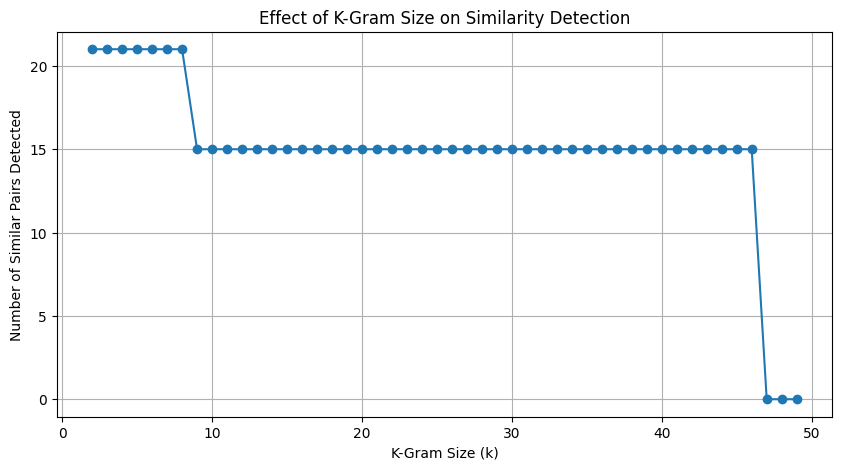

In [ ]:
# K values to test
k_values = list(range(2, 50))  # Test k from 2 to 50

# Initialize and run the tuning process
tuner = MOSS_KGram_Tuning(non_plagiarized_code1,"java", k_values, MOSS)
tuner.run_tuning()
tuner.plot_results()

Case02 k-gram tuning

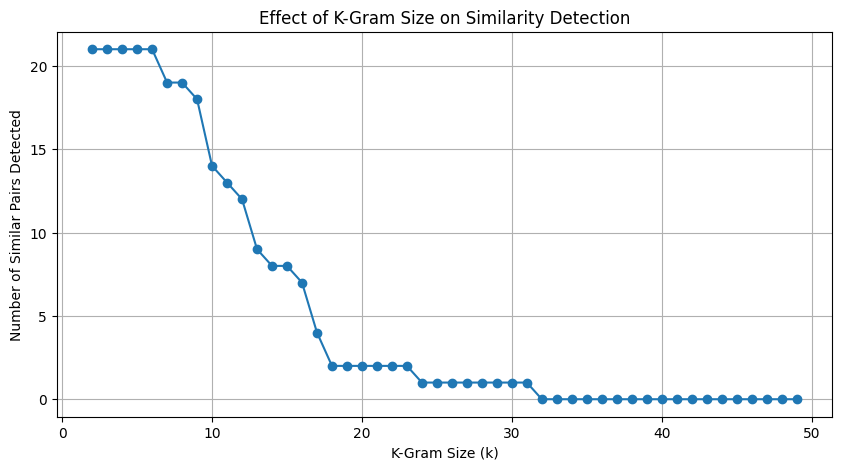

In [ ]:
# K values to test
k_values = list(range(2, 50))  # Test k from 2 to 50

# Initialize and run the tuning process
tuner = MOSS_KGram_Tuning(non_plagiarized_code2,"java", k_values, MOSS)
tuner.run_tuning()
tuner.plot_results()

Case03 k-gram tuning

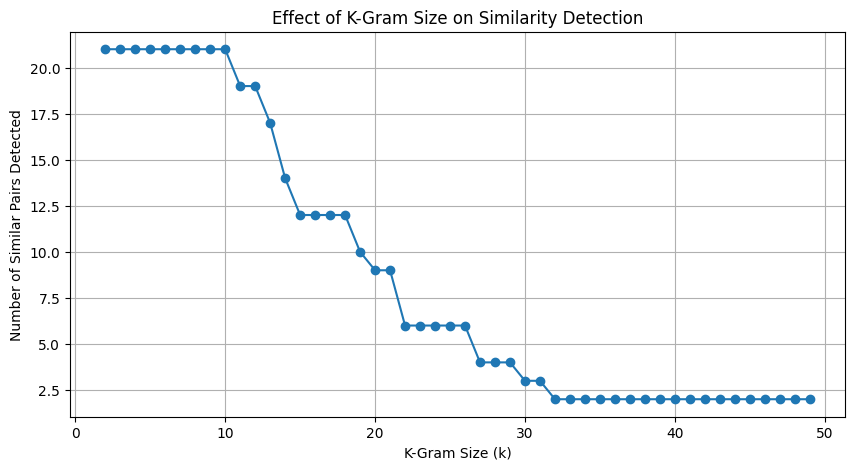

In [ ]:
# K values to test
k_values = list(range(2, 50))  # Test k from 2 to 50

# Initialize and run the tuning process
tuner = MOSS_KGram_Tuning(non_plagiarized_code3,"java", k_values, MOSS)
tuner.run_tuning()
tuner.plot_results()

Case04 k-gram tuning

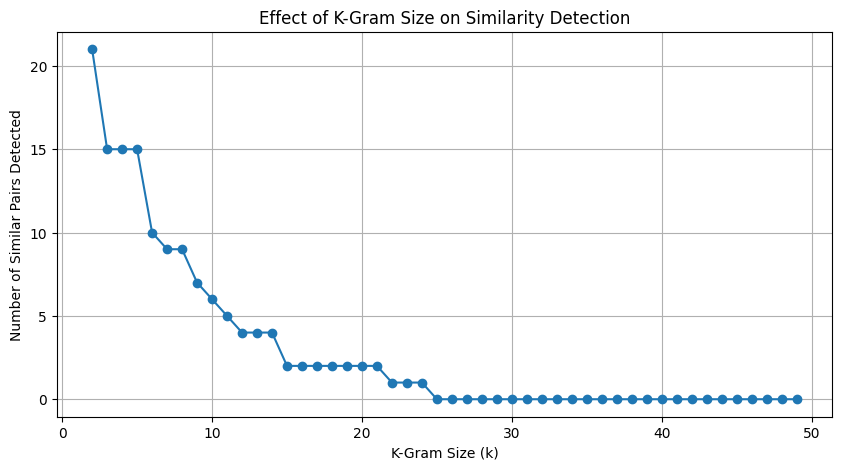

In [ ]:
# K values to test
k_values = list(range(2, 50))  # Test k from 2 to 50

# Initialize and run the tuning process
tuner = MOSS_KGram_Tuning(non_plagiarized_code4,"java", k_values, MOSS)
tuner.run_tuning()
tuner.plot_results()

Case05 k-gram tuning

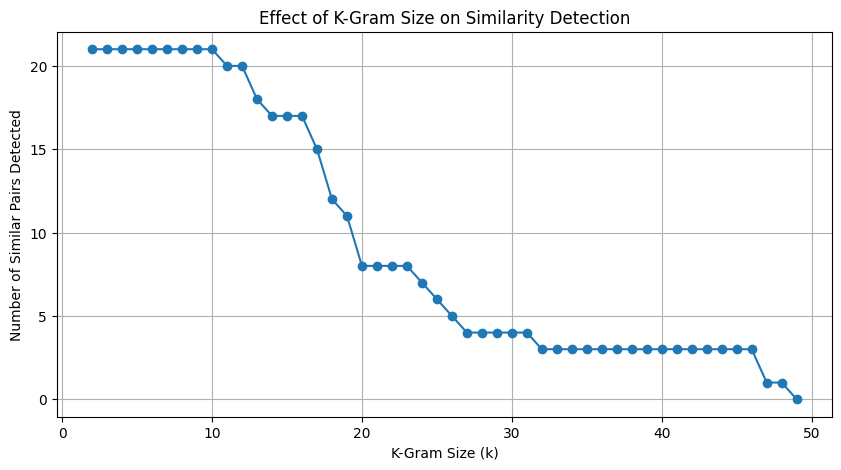

In [ ]:
# K values to test
k_values = list(range(2, 50))  # Test k from 2 to 50

# Initialize and run the tuning process
tuner = MOSS_KGram_Tuning(non_plagiarized_code5,"java", k_values, MOSS)
tuner.run_tuning()
tuner.plot_results()

Case06 k-gram tuning

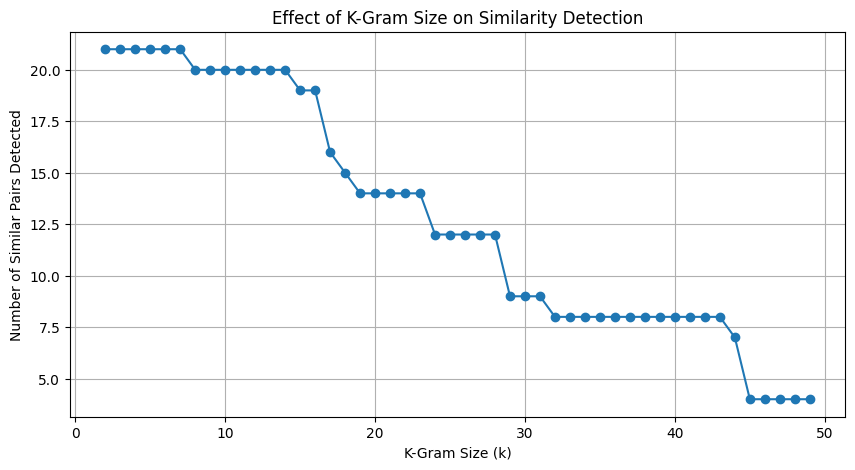

In [ ]:
# K values to test
k_values = list(range(2, 50))  # Test k from 2 to 50

# Initialize and run the tuning process
tuner = MOSS_KGram_Tuning(non_plagiarized_code6,"java", k_values, MOSS)
tuner.run_tuning()
tuner.plot_results()

Case07 k-gram tuning

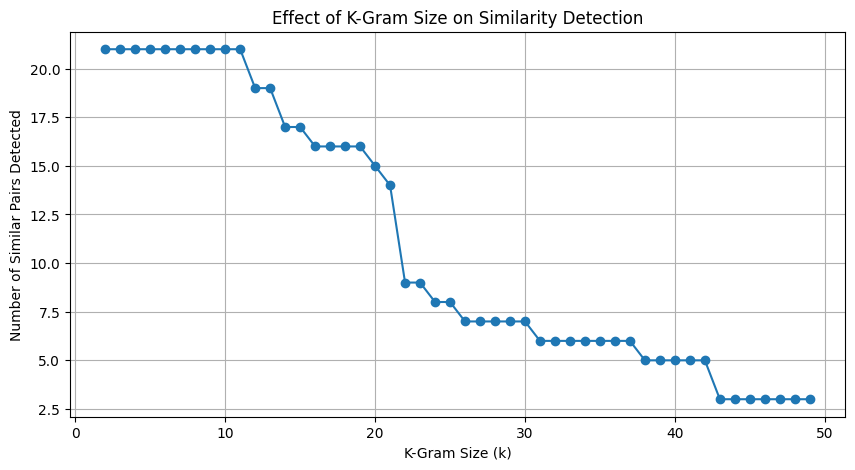

In [ ]:
# K values to test
k_values = list(range(2, 50))  # Test k from 2 to 50

# Initialize and run the tuning process
tuner = MOSS_KGram_Tuning(non_plagiarized_code7,"java", k_values, MOSS)
tuner.run_tuning()
tuner.plot_results()

When the value for k is too small it flags common code structures as plagiarism (giving high number of similar pairs).

When the value of k is too large it overlooks actual cases of similar pairs (giving low number of similar pairs).

It is found that the optimal value for k is 15 around the point after the decline begins.

### Window size tuning

In [ ]:
class MOSS_Window_Tuning:
    def __init__(self, original_code, plagiarized_samples, non_plagiarized_samples, language, w_values, n=20):
        self.original_code = original_code  #the single original sample
        self.plagiarized_samples = plagiarized_samples  #list of plagiarized versions
        self.non_plagiarized_samples = non_plagiarized_samples  #list of non-plagiarized versions
        self.language = language  #programming language
        self.w_values = w_values  #list of window sizes to test
        self.n = n  #k-gram size
        self.results = {}  #store similarity results

    def compute_fingerprints(self, code, w):
        """ Run MOSS algorithm for a given code and window size w """
        moss = MOSS(code, self.language, n=self.n, window_size=w)
        moss.run()  #generates fingerprints
        return set(fp[0] for fp in moss.fingerprints)  #extract only fingerprint hashes

    def similarity(self, set1, set2):
        """ Compute similarity between two fingerprint sets """
        common = set1.intersection(set2)
        total = len(set1.union(set2))
        if not common:
          return 0
        return len(common) / total
        #return len(set1 & set2) / len(set1 | set2) if set1 | set2 else 0

    def run_tuning(self):
        """ Run parameter tuning for different window sizes (w) """
        #use only half(to prevent leakage)
        half_plagiarized_samples = self.plagiarized_samples[:len(self.plagiarized_samples) // 2]
        half_non_plagiarized_samples = self.non_plagiarized_samples[:len(self.non_plagiarized_samples) // 2]

        for w in self.w_values:
            #compute fingerprints for original, plagiarized, and non-plagiarized samples
            original_fps = self.compute_fingerprints(self.original_code, w)

            plagiarized_similarities = []
            non_plagiarized_similarities = []

            #compare plagiarized samples
            for sample in half_plagiarized_samples:
                sample_fps = self.compute_fingerprints(sample, w)
                plagiarized_similarities.append(self.similarity(original_fps, sample_fps))

            #compare non-plagiarized samples
            for sample in half_non_plagiarized_samples:
                sample_fps = self.compute_fingerprints(sample, w)
                non_plagiarized_similarities.append(self.similarity(original_fps, sample_fps))

            #store average similarities for this window size
            avg_plagiarized = sum(plagiarized_similarities) / len(plagiarized_similarities)
            avg_non_plagiarized = sum(non_plagiarized_similarities) / len(non_plagiarized_similarities)
            self.results[w] = (avg_plagiarized, avg_non_plagiarized)

    def plot_results(self):
        """ Plot similarity scores for different window sizes """
        w_values = list(self.results.keys())
        plagiarized_scores = [self.results[w][0] for w in w_values]
        non_plagiarized_scores = [self.results[w][1] for w in w_values]

        plt.figure(figsize=(10, 5))
        plt.plot(w_values, plagiarized_scores, marker='o', linestyle='-', label="Plagiarized Similarity")
        plt.plot(w_values, non_plagiarized_scores, marker='o', linestyle='--', label="Non-Plagiarized Similarity")
        plt.xlabel("Window Size (w)")
        plt.ylabel("Average Similarity")
        plt.title("Effect of Window Size on Similarity Detection")
        plt.legend()
        plt.grid(True)
        plt.show()


Case01 window-size tuning

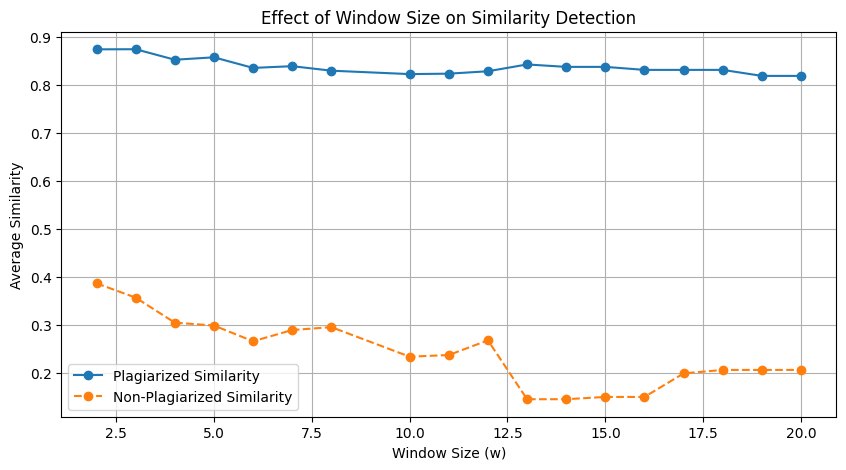

In [ ]:
#define window size values to test
w_values = [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

#run tuning
tuner = MOSS_Window_Tuning(original_code1[0], plagiarized_code1, non_plagiarized_code1,"java", w_values, n=5)
tuner.run_tuning()
tuner.plot_results()

Case02 window-size tuning

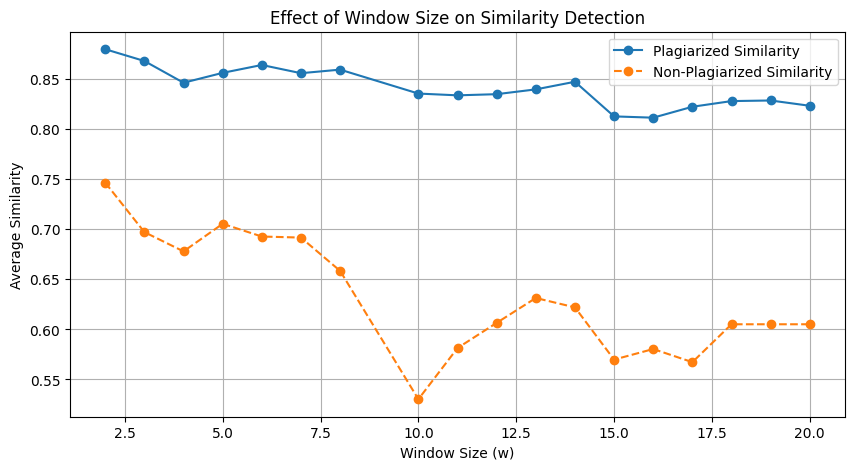

In [ ]:
#define window size values to test
w_values = [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

#run tuning
tuner = MOSS_Window_Tuning(original_code2[0], plagiarized_code2, non_plagiarized_code2,"java", w_values, n=5)
tuner.run_tuning()
tuner.plot_results()

Case03 window-size tuning

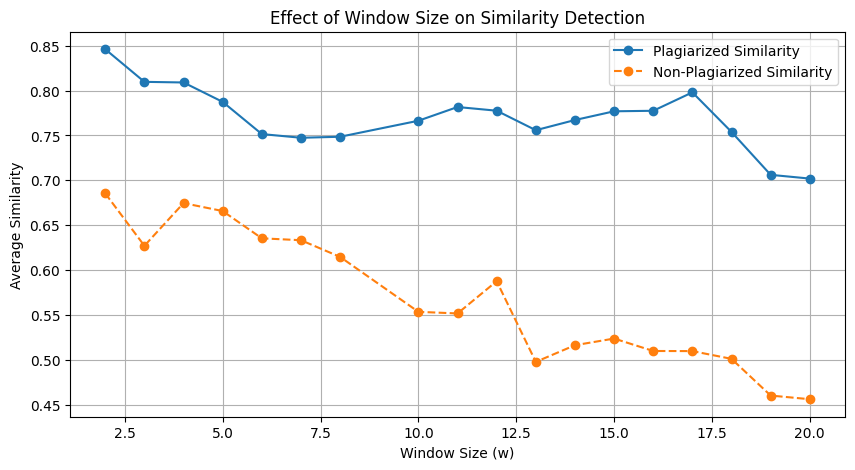

In [ ]:
#define window size values to test
w_values = [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

#run tuning
tuner = MOSS_Window_Tuning(original_code3[0], plagiarized_code3, non_plagiarized_code3,"java", w_values, n=15)
tuner.run_tuning()
tuner.plot_results()

Case04 window-size tuning

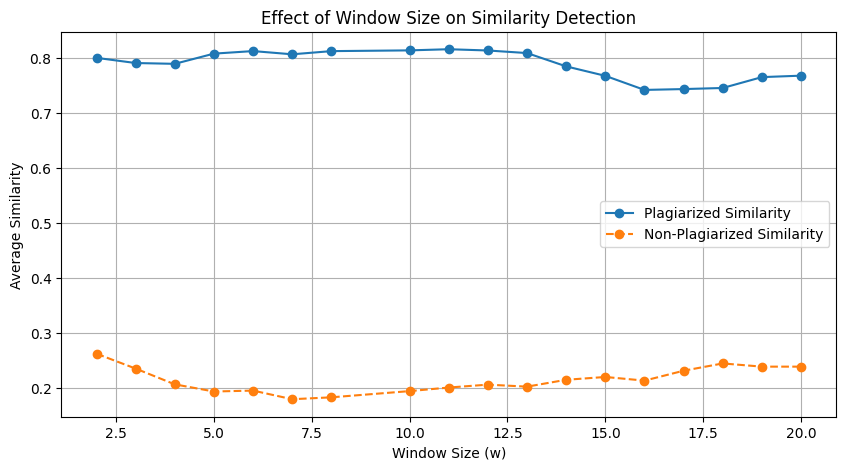

In [ ]:
#define window size values to test
w_values = [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

#run tuning
tuner = MOSS_Window_Tuning(original_code4[0], plagiarized_code4, non_plagiarized_code4,"java", w_values, n=15)
tuner.run_tuning()
tuner.plot_results()

Case05 window-size tuning

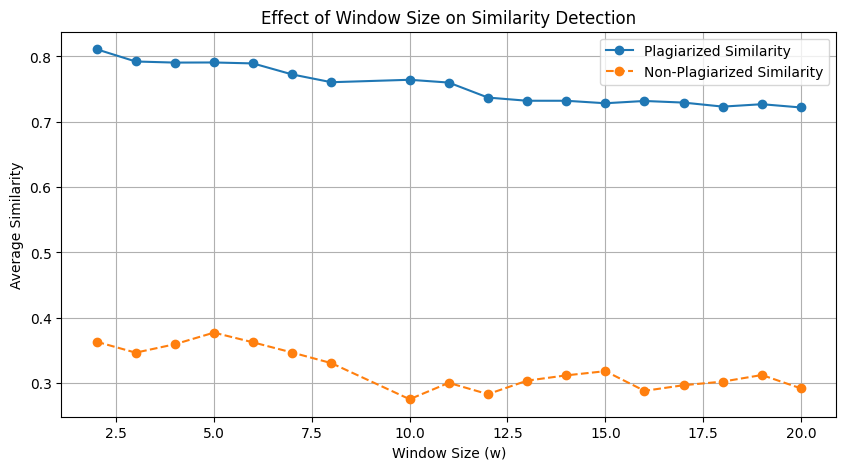

In [ ]:
#define window size values to test
w_values = [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

#run tuning
tuner = MOSS_Window_Tuning(original_code5[0], plagiarized_code5, non_plagiarized_code5,"java", w_values, n=15)
tuner.run_tuning()
tuner.plot_results()

Case06 window-size tuning

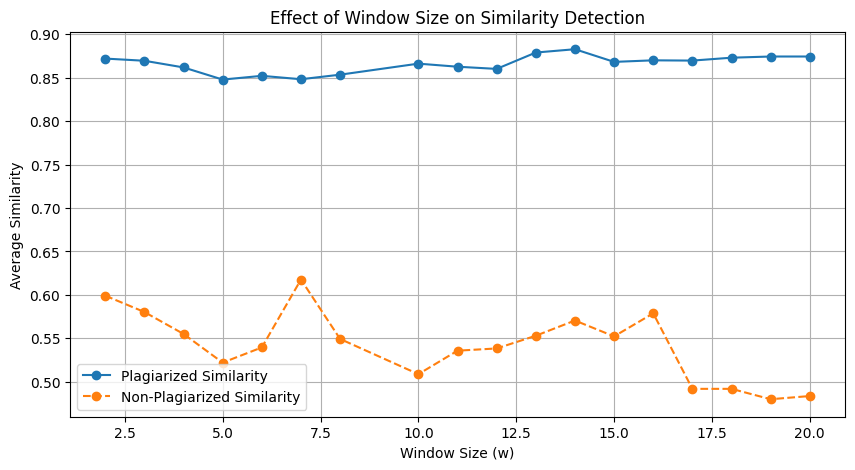

In [ ]:
#define window size values to test
w_values = [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

#run tuning
tuner = MOSS_Window_Tuning(original_code6[0], plagiarized_code6, non_plagiarized_code6,"java", w_values, n=15)
tuner.run_tuning()
tuner.plot_results()

Case07 window-size tuning

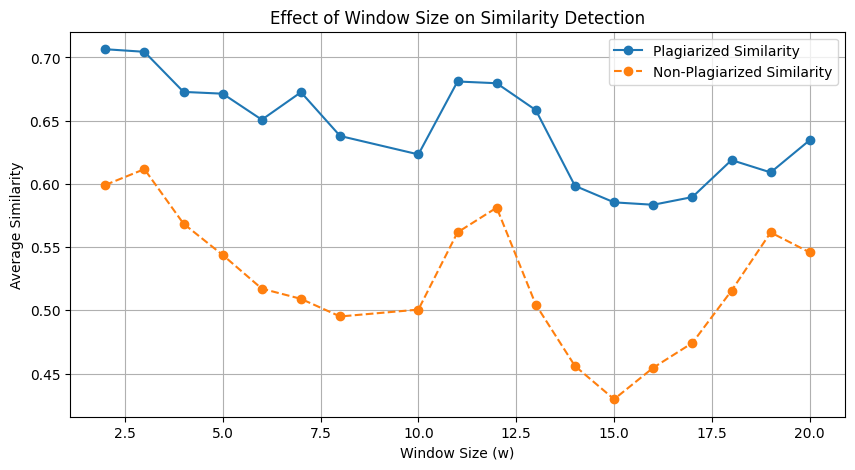

In [ ]:
#define window size values to test
w_values = [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

#run tuning
tuner = MOSS_Window_Tuning(original_code7[0], plagiarized_code7, non_plagiarized_code7,"java", w_values, n=15)
tuner.run_tuning()
tuner.plot_results()

The optimal value for the window size was chosen as 10. This value helps to maximise the difference between plagiarized and non-plagiarized code samples.

### Precision, Recall and F1
To test the effectiveness of the MOSS algorithm after parameter tuning was comleted, only used **Comparator based on Jaccard Similarity**.

In [ ]:
class MOSS_Evaluation:
    def __init__(self, file_contents, language, comparator_class, moss_class, n=15, window_size=10):
        """
        Initializes the MOSS evaluation class with file contents.
        """
        self.plagiarized_code = file_contents['plagiarized']
        self.non_plagiarized_code = file_contents['non-plagiarized']

        #combine code samples and create labels
        self.code_samples = self.plagiarized_code + self.non_plagiarized_code
        self.labels = [1] * len(self.plagiarized_code) + [0] * len(self.non_plagiarized_code)

        self.language = language
        self.comparator_class = comparator_class
        self.moss_class = moss_class
        self.n = n
        self.window_size = window_size
        self.predictions = []

    def run_comparisons(self):
        """
        Runs the comparison for all pairs of code samples and stores the predicted labels.
        """
        #generate MOSS instances for each code sample
        moss_instances = []
        for code in self.code_samples:
            moss = self.moss_class(code, self.language, n=self.n, window_size=self.window_size)
            moss.run()
            moss_instances.append(moss)

        #compare all possible pairs
        self.predictions = []
        for (i, moss1), (j, moss2) in combinations(enumerate(moss_instances), 2):
            comparator = self.comparator_class(moss_instance_1=moss1, moss_instance_2=moss2)
            similarity_score = comparator.compare()

            #assuming a threshold of 0.2 for determining plagiarism
            predicted_label = 1 if similarity_score > 20 else 0
            self.predictions.append((i, j, predicted_label))

    def evaluate_metrics(self):
        """
        Evaluates Precision, Recall, and F1 Score.
        """
        y_true = []
        y_pred = []

        for i, j, pred_label in self.predictions:
            #the ground truth is 1 if either of the samples are labeled as plagiarized
            true_label = 1 if self.labels[i] == 1 or self.labels[j] == 1 else 0
            y_true.append(true_label)
            y_pred.append(pred_label)

        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        print(f"Precision: {precision:.2f}")
        print(f"Recall: {recall:.2f}")
        print(f"F1 Score: {f1:.2f}")

        return {
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    def plot_metrics(self, metrics):
        """
        Plots the evaluation metrics as a bar graph.

        """
        plt.figure(figsize=(8, 6))
        sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), hue=list(metrics.keys()), palette='viridis', dodge=False)
        plt.ylim(0, 1)
        plt.title("MOSS Algorithm Effectiveness Metrics")
        plt.xlabel("Metrics")
        plt.ylabel("Score")
        plt.legend([], [], frameon=False)
        plt.show()

    def run(self):
        """
        Runs the MOSS evaluation.
        """
        self.run_comparisons()
        metrics = self.evaluate_metrics()
        self.plot_metrics(metrics)


Case01 Evaluation

Precision: 0.89
Recall: 0.62
F1 Score: 0.73


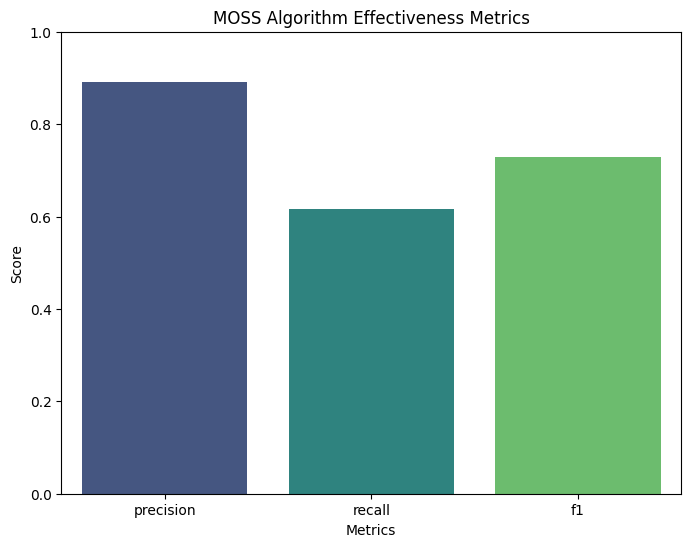

In [ ]:
# initialize and run the MOSS evaluation
evaluator = MOSS_Evaluation(
    file_contents=file_contents1,
    language="java",
    comparator_class=Comparator,
    moss_class=MOSS,
    n=5,
    window_size=10
)

evaluator.run()

Case02 Evaluation

Precision: 0.96
Recall: 1.00
F1 Score: 0.98


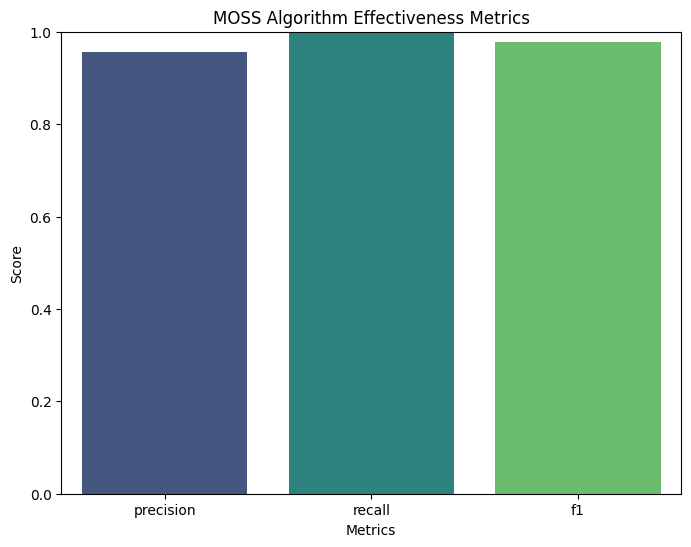

In [ ]:
# initialize and run the MOSS evaluation
evaluator = MOSS_Evaluation(
    file_contents=file_contents2,
    language="java",
    comparator_class=Comparator,
    moss_class=MOSS,
    n=5,
    window_size=10
)

evaluator.run()

Case03 Evaluation

Precision: 0.95
Recall: 1.00
F1 Score: 0.98


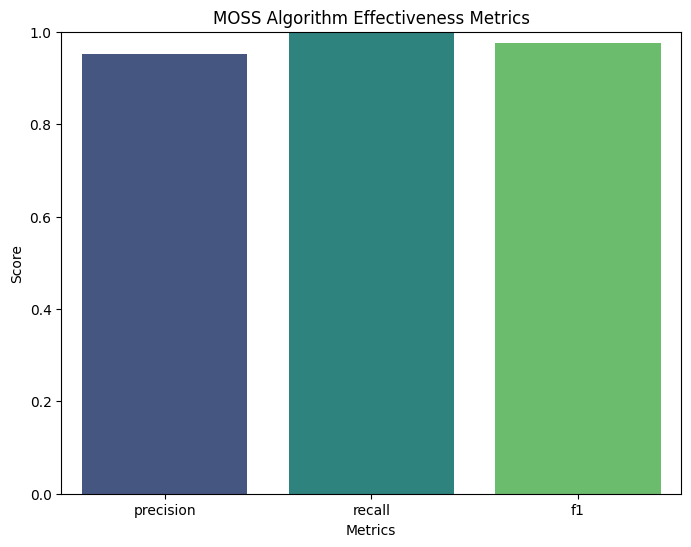

In [ ]:
# initialize and run the MOSS evaluation
evaluator = MOSS_Evaluation(
    file_contents=file_contents3,
    language="java",
    comparator_class=Comparator,
    moss_class=MOSS,
    n=15,
    window_size=10
)

evaluator.run()

Case04 Evaluation

Precision: 0.96
Recall: 0.82
F1 Score: 0.89


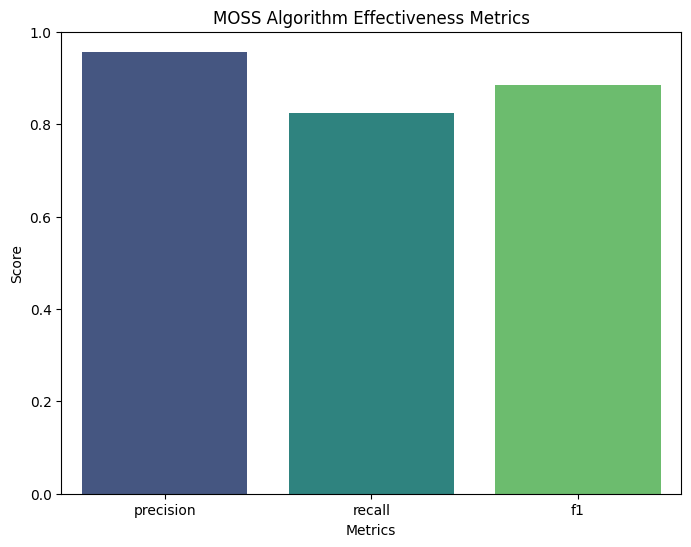

In [ ]:
# initialize and run the MOSS evaluation
evaluator = MOSS_Evaluation(
    file_contents=file_contents4,
    language="java",
    comparator_class=Comparator,
    moss_class=MOSS,
    n=15,
    window_size=10
)

evaluator.run()

Case05 Evaluation

Precision: 0.95
Recall: 0.91
F1 Score: 0.93


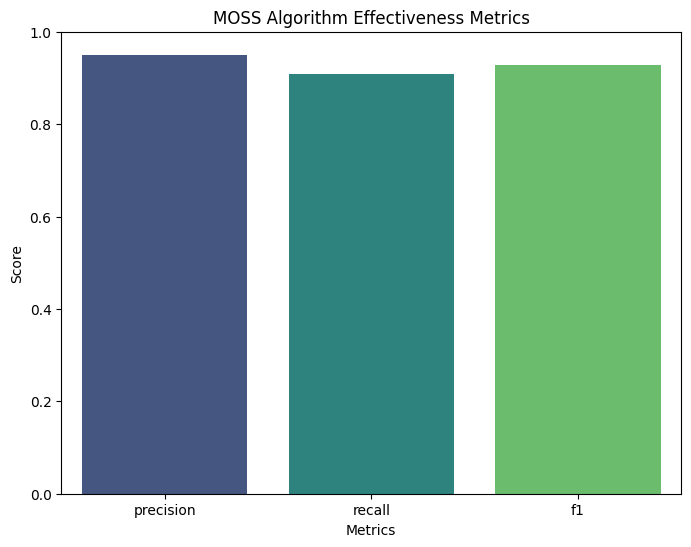

In [ ]:
# initialize and run the MOSS evaluation
evaluator = MOSS_Evaluation(
    file_contents=file_contents5,
    language="java",
    comparator_class=Comparator,
    moss_class=MOSS,
    n=15,
    window_size=10
)

evaluator.run()

Case06 Evaluation

Precision: 0.95
Recall: 0.99
F1 Score: 0.97


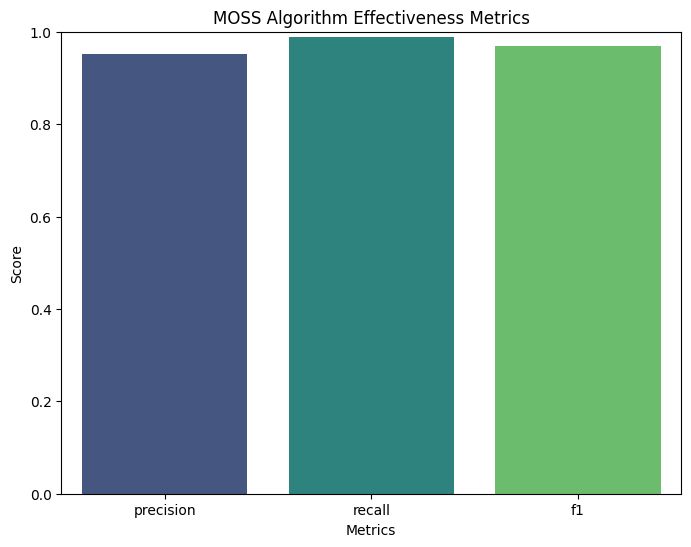

In [ ]:
# initialize and run the MOSS evaluation
evaluator = MOSS_Evaluation(
    file_contents=file_contents6,
    language="java",
    comparator_class=Comparator,
    moss_class=MOSS,
    n=15,
    window_size=10
)

evaluator.run()

Case07 Evaluation

Precision: 0.95
Recall: 1.00
F1 Score: 0.97


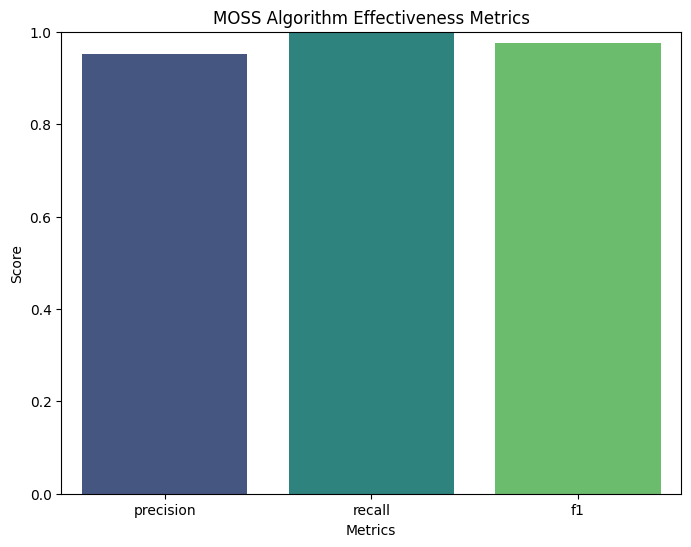

In [ ]:
# initialize and run the MOSS evaluation
evaluator = MOSS_Evaluation(
    file_contents=file_contents7,
    language="java",
    comparator_class=Comparator,
    moss_class=MOSS,
    n=15,
    window_size=10
)

evaluator.run()

## Experiments on code samples generated using AI

Using code prompts from each case sample (case01-07), generate code using ChatGPT and use these as the AI-generated dataset.
- First test: Naive test, generate 10 samples just using the prompt
- Second test: Adaptations test, ask ChatGPT to use different approaches to solve the propmt


In [ ]:
class MOSS_Fingerprint_Comparison:
  def __init__(self, code_samples, language, comparator_class, ai_generated_code=None, non_plagiarized_code=None, n=20, window_size=10):
        self.code_samples = code_samples  # List of code samples
        self.ai_generated_code = ai_generated_code #optional
        self.non_plagiarized_code = non_plagiarized_code #optional
        self.language = language
        self.comparator_class = comparator_class
        self.n = n  # K-gram size
        self.window_size = window_size  # Window size for winnowing
        self.moss_instances = []  # Store MOSS instances for each sample
        self.moss_ai_instances = []
        self.moss_non_plag_instances = []
        self.similarity_matrix = None
        self.similarity_scores = []

  def generate_fingerprints(self):
        """Generates fingerprints for each code sample using the MOSS class"""
        for code in self.code_samples:
            moss = MOSS(code, self.language, n=self.n, window_size=self.window_size)
            moss.run()  # Run the full MOSS pipeline for each code sample
            self.moss_instances.append(moss)

  def compute_similarity_matrix(self):
      """Computes the similarity matrix using the Comparator class"""
      num_samples = len(self.moss_instances)
      self.similarity_matrix = np.zeros((num_samples, num_samples))

      for i in range(num_samples):
          for j in range(num_samples):
              if i != j:
                  comparator = self.comparator_class(moss_instance_1=self.moss_instances[i], moss_instance_2=self.moss_instances[j])
                  similarity_score = comparator.compare()
                  self.similarity_matrix[i, j] = similarity_score
              else:
                  self.similarity_matrix[i, j] = 100  # Self-similarity is 100%

  def plot_heatmap(self):
      """Visualizes the similarity matrix using a heatmap"""
      plt.figure(figsize=(8, 6))
      sns.heatmap(
          self.similarity_matrix,
          annot=True,
          cmap="YlGnBu",
          fmt=".2f",
          xticklabels=[f"Code {i+1}" for i in range(len(self.code_samples))],
          yticklabels=[f"Code {i+1}" for i in range(len(self.code_samples))],
          vmin=0, vmax=100
      )
      plt.title("Code Similarity Heatmap (Similarity %)")
      plt.xlabel("AI Code Samples")
      plt.ylabel("AI Code Samples")
      plt.show()

  def compare_ai_vs_ai(self):
    """Compares AI-generated code vs. AI-genearated code"""
    if not self.ai_generated_code:
      raise ValueError("AI-generated code samples must be given")

    #generate fingerprints for each
    self.moss_ai_instances = []
    self.moss_ai_instances1 = []

    for code in self.ai_generated_code:
      moss = MOSS(code, self.language, n=self.n, window_size=self.window_size)
      moss.run()
      self.moss_ai_instances.append(moss)
      self.moss_ai_instances1.append(moss)

    #compute similarity scores
    self.similarity_scores = []
    for moss_ai in self.moss_ai_instances:
      for moss_ai1 in self.moss_ai_instances:
        comparator  = self.comparator_class(moss_instance_1=moss_ai, moss_instance_2=moss_ai1)
        similarity_score = comparator.compare()
        self.similarity_scores.append(similarity_score)

  def compare_ai_vs_non_plag(self):
    """Compares AI-generated code vs. non-plagiarized code"""
    if not self.ai_generated_code or not self.non_plagiarized_code:
      raise ValueError("AI-generated & non-plagiarized code samples must be given")

    #generate fingerprints for each
    self.moss_ai_instances = []
    self.moss_non_plag_instances = []

    for code in self.ai_generated_code:
      moss = MOSS(code, self.language, n=self.n, window_size=self.window_size)
      moss.run()
      self.moss_ai_instances.append(moss)

    for code in self.non_plagiarized_code:
      moss = MOSS(code, self.language, n=self.n, window_size=self.window_size)
      moss.run()
      self.moss_non_plag_instances.append(moss)

    #compute similarity scores
    self.similarity_scores = []
    for moss_ai in self.moss_ai_instances:
      for moss_non_plag in self.moss_non_plag_instances:
        comparator  = self.comparator_class(moss_instance_1=moss_ai, moss_instance_2=moss_non_plag)
        similarity_score = comparator.compare()
        self.similarity_scores.append(similarity_score)

  def plot_similarity_distribution(self):
      """Plots the similarity distribution for AI vs. Non-Plagiarized"""
      plt.figure(figsize=(12, 6))
      sns.histplot(self.similarity_scores, kde=True, bins=15, color='blue', alpha=0.7)
      plt.axvline(np.mean(self.similarity_scores), color='red', linestyle='dashed', label=f'Mean Similarity: {np.mean(self.similarity_scores):.2f}')
      plt.xlabel("Similarity Score")
      plt.ylabel("Frequency")
      plt.title("Similarity Distribution: AI-Generated vs Non-Plagiarized Code")
      plt.legend()
      plt.show()

  def plot_similarity_distribution_ai(self):
      """Plots the similarity distribution for AI vs. AI"""
      plt.figure(figsize=(12, 6))
      sns.histplot(self.similarity_scores, kde=True, bins=15, color='green', alpha=0.7)
      plt.axvline(np.mean(self.similarity_scores), color='red', linestyle='dashed', label=f'Mean Similarity: {np.mean(self.similarity_scores):.2f}')
      plt.xlabel("Similarity Score")
      plt.ylabel("Frequency")
      plt.title("Similarity Distribution: AI-Generated vs AI-Generated")
      plt.legend()
      plt.show()

  def run(self):
      """Run all steps for comparison and visualisation"""
      self.generate_fingerprints()
      self.compute_similarity_matrix()
      self.plot_heatmap()

  def run_ai_vs_non_plag_comparison(self):
    """Runs the AI vs. non-plagiarised fingerprinting and visualisation"""
    self.compare_ai_vs_non_plag()
    self.plot_similarity_distribution()

  def run_ai_vs_ai_comparison(self):
    """Runs the AI vs. AI fingerprinting and visualisation"""
    self.compare_ai_vs_ai()
    self.plot_similarity_distribution_ai()

### Naive test:
Preliminary test: check AI genearated code simimlarity with itself
Test: check similarity of AI generated code with non-plagiarised code samples
Using Naive Ai-generated code samples

In [ ]:
#EXTRACT DATA FOR NAIVE TESTS FIRST

directory_path1 = './drive/My Drive/FYP/AI_Generated_code/case_01/Naive'
directory_path2 = './drive/My Drive/FYP/AI_Generated_code/case_02/Naive'
directory_path3 = './drive/My Drive/FYP/AI_Generated_code/case_03/Naive'
directory_path4 = './drive/My Drive/FYP/AI_Generated_code/case_04/Naive'
directory_path5 = './drive/My Drive/FYP/AI_Generated_code/case_05/Naive'
directory_path6 = './drive/My Drive/FYP/AI_Generated_code/case_06/Naive'
directory_path7 = './drive/My Drive/FYP/AI_Generated_code/case_07/Naive'


def read_files_from_directory(directory_path, file_extension = '.java'):
    """
    Function to read files from a given directory path
    """
    # Dictionary to store file names as keys and file contents as values
    java_files_dict = {}
    file_data = []
    for filename in os.listdir(directory_path):
        if filename.endswith('.java'):
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read()
                java_files_dict[filename] = content
                file_data.append(content)
    return java_files_dict, file_data

dictionary_1 , ai_files1= read_files_from_directory(directory_path1)
dictionary_2 , ai_files2= read_files_from_directory(directory_path2)
dictionary_3 , ai_files3= read_files_from_directory(directory_path3)
dictionary_4 , ai_files4= read_files_from_directory(directory_path4)
dictionary_5 , ai_files5= read_files_from_directory(directory_path5)
dictionary_6 , ai_files6= read_files_from_directory(directory_path6)
dictionary_7 , ai_files7= read_files_from_directory(directory_path7)



#### Prompt from case 01
Prompt: Write a program that prints "Welcome to Java" five times.

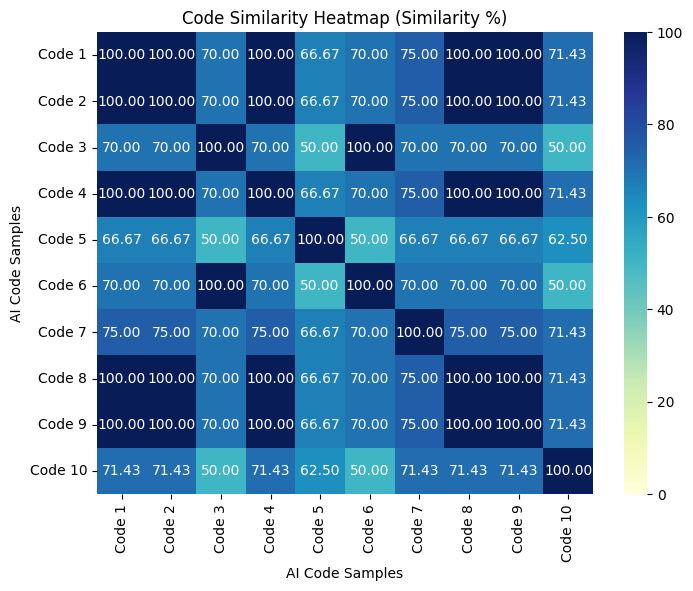

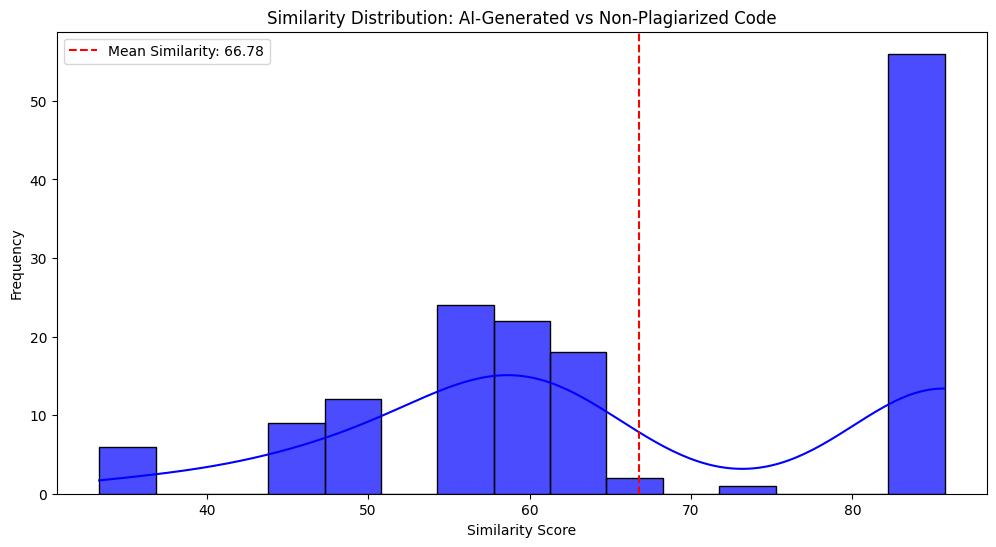

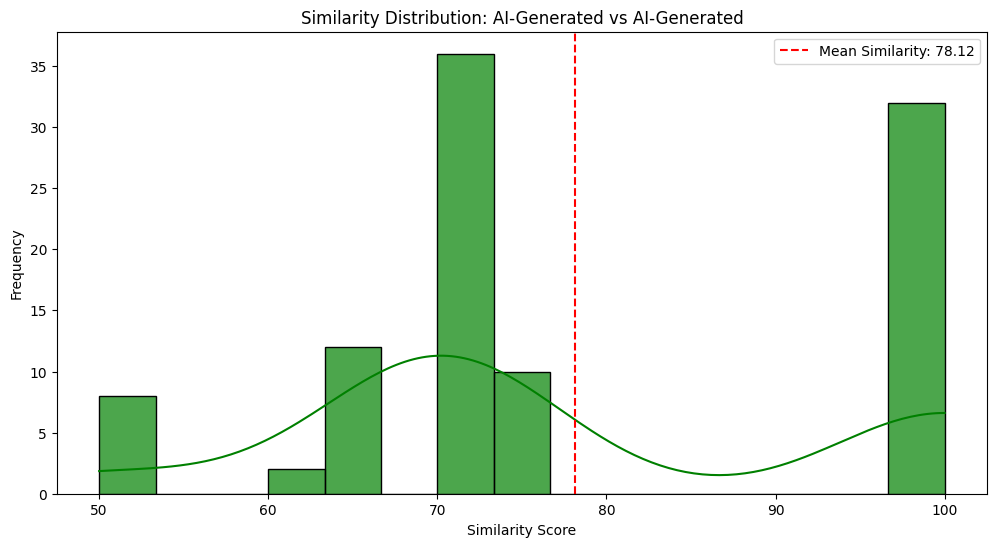

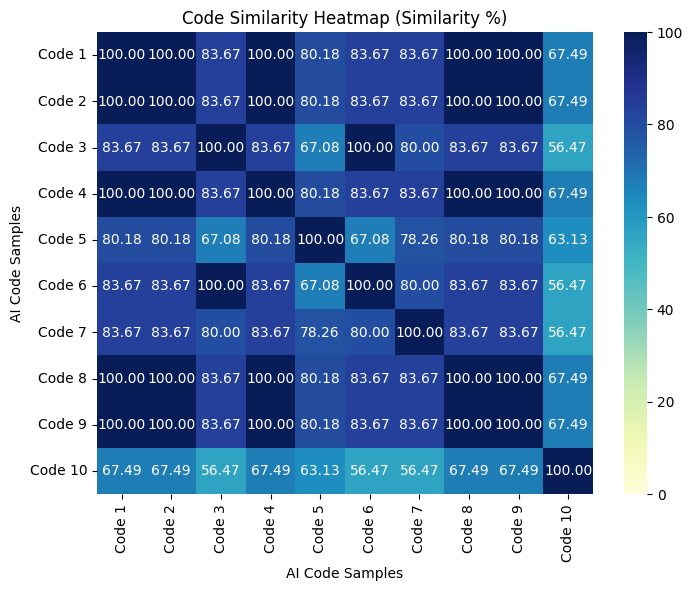

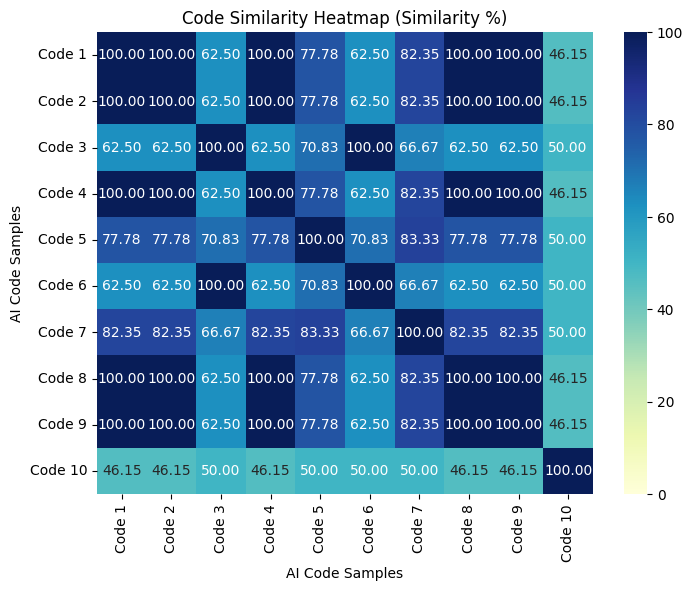

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples= ai_files1, ai_generated_code=ai_files1, non_plagiarized_code=non_plagiarized_code1, language="java", comparator_class=Comparator, n=5, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

comparison = MOSS_Fingerprint_Comparison(ai_files1, "java", Comparator2, n=5, window_size=10)
comparison.run()

comparison = MOSS_Fingerprint_Comparison(ai_files1, "java", Comparator3, n=5, window_size=10)
comparison.run()

#### Prompt from case 02
Prompt: Write a program that accepts the radius & length of a cylinder and prints the area & volume of that cylinder. All inputs and outputs are real numbers. Cylinder's area = radius * radius * 3.14159, Cylinder's volume = area * length.

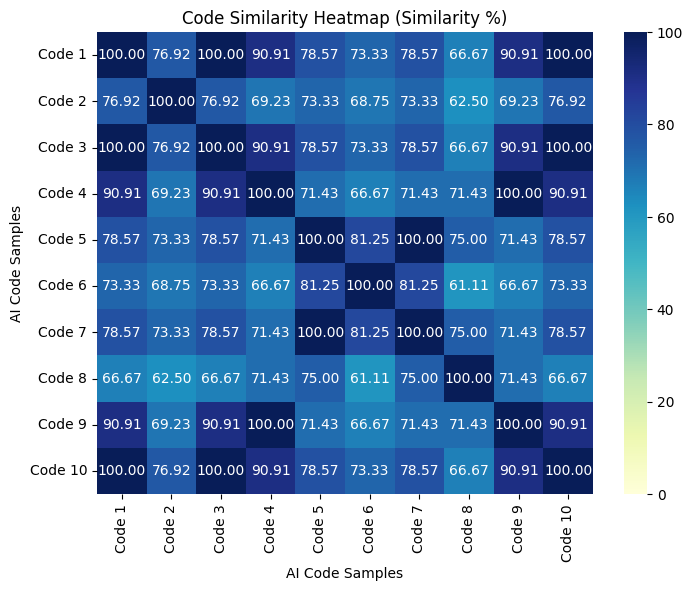

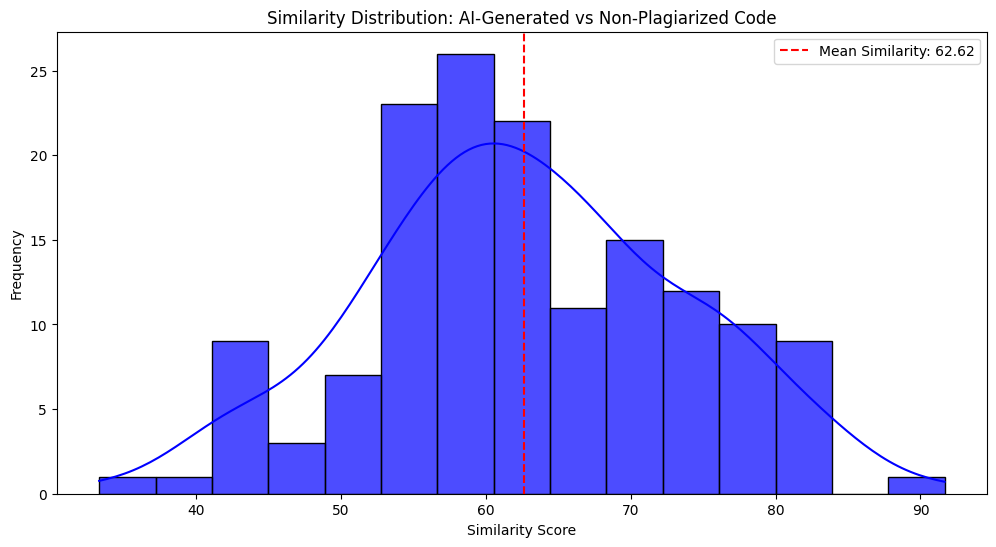

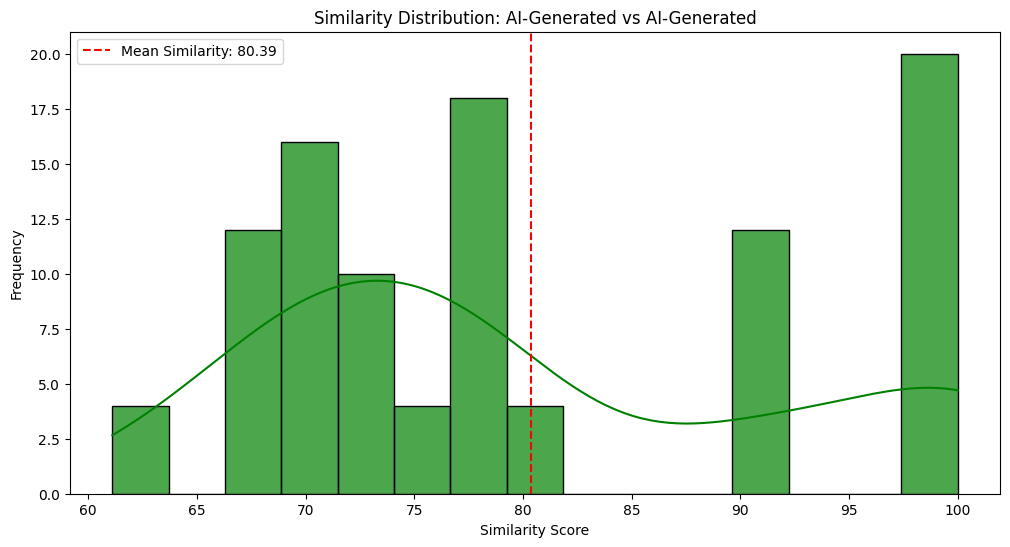

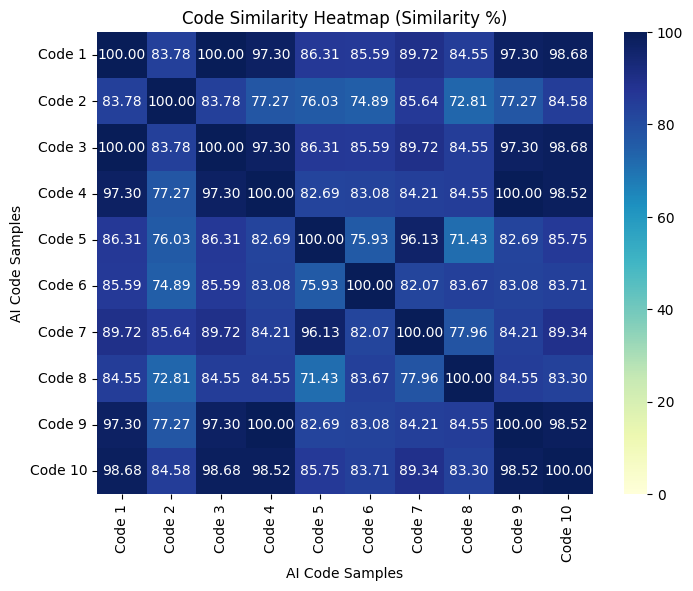

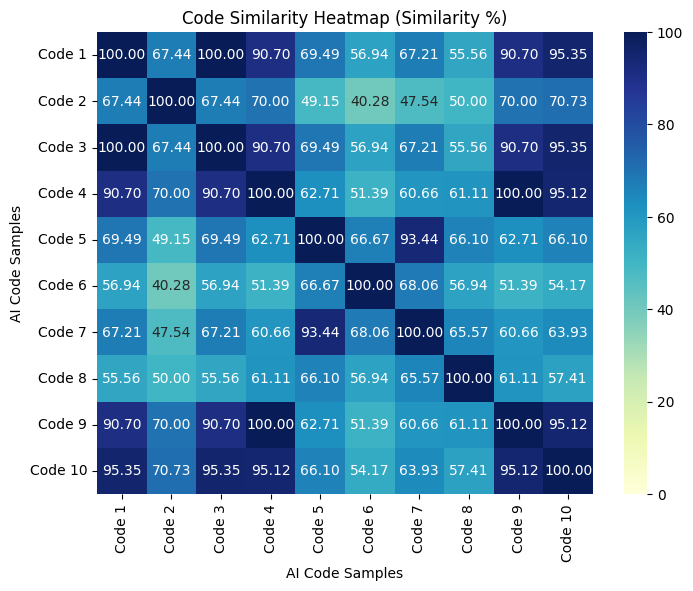

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files2, ai_generated_code=ai_files2, non_plagiarized_code=non_plagiarized_code2, language="java", comparator_class=Comparator, n=5, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()


comparison = MOSS_Fingerprint_Comparison(ai_files2, "java", Comparator2, n=5, window_size=10)
comparison.run()

comparison = MOSS_Fingerprint_Comparison(ai_files2, "java", Comparator3, n=5, window_size=10)
comparison.run()

#### Prompt from case 03
Prompt: Write a program that accepts the weight (as a real number representing pound) and height (as two real numbers representing feet and inches respectively) of a person. Upon accepting input, the program will show that person's BMI(real number) and a piece of information stating whether the BMI is categorised as underweight, normal, overweight, or obese. A person is underweight if BMI < 18.5; normal if 18.5 <= BMI < 25; overweight if 25 <= BMI < 35; or obese if BMI >= 35. Height = feet * 12 +inches BMI = weight * 0.45359237 / (height * 0.0254)^2.

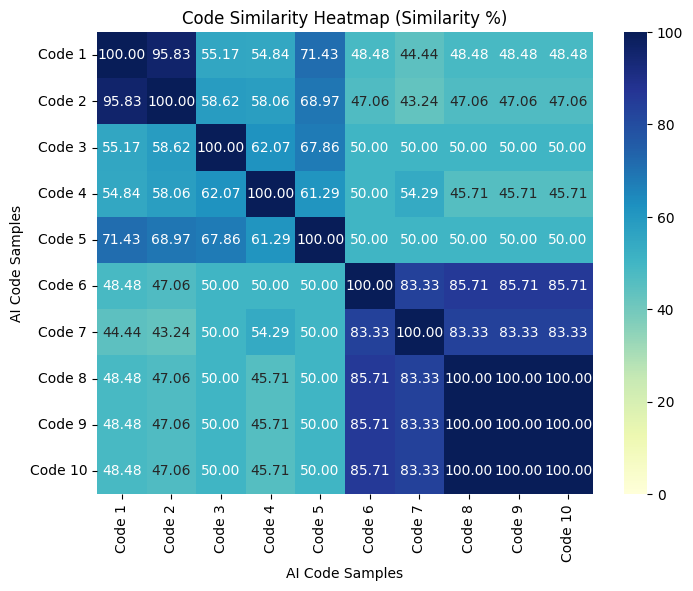

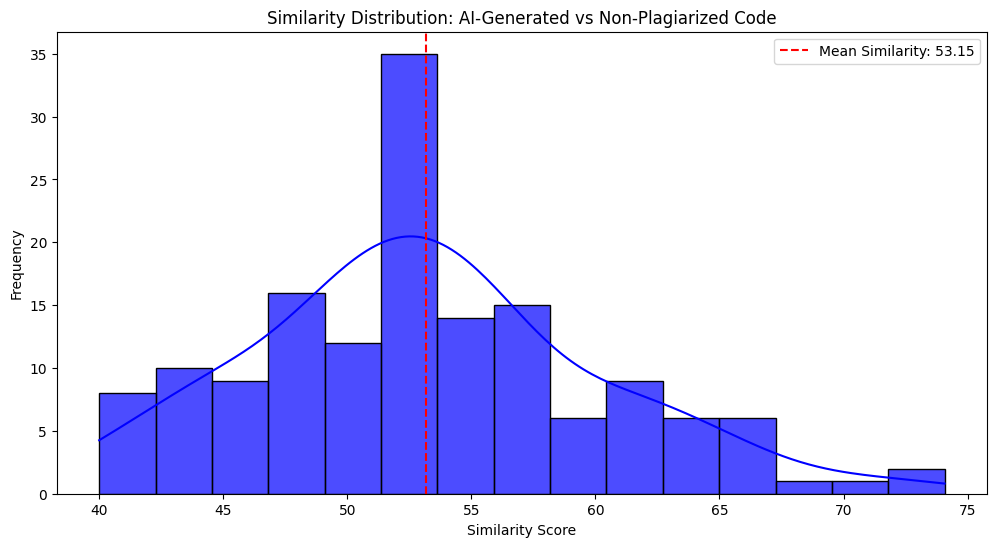

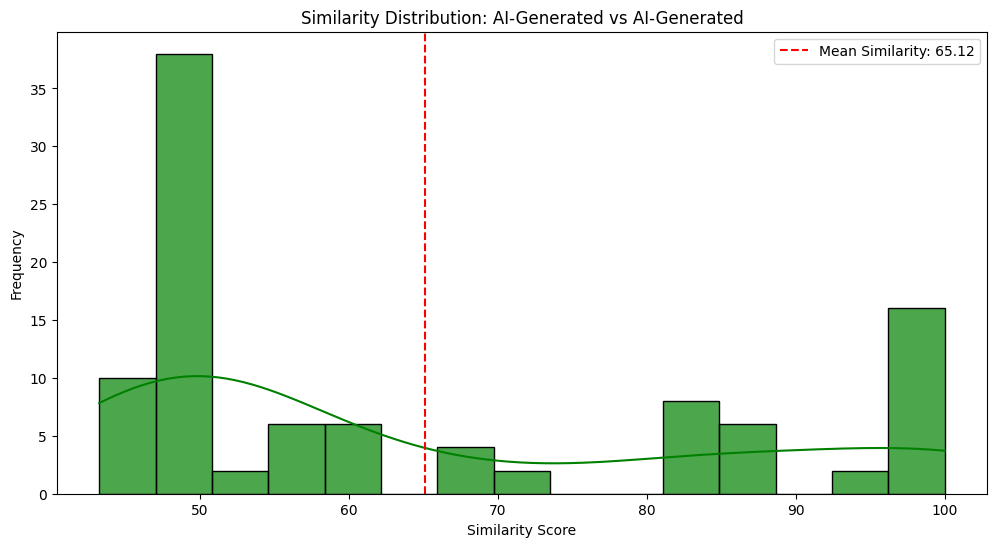

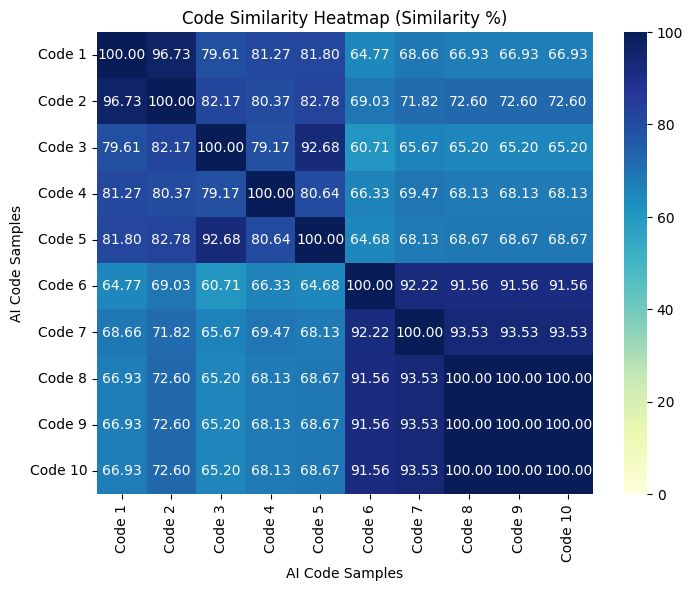

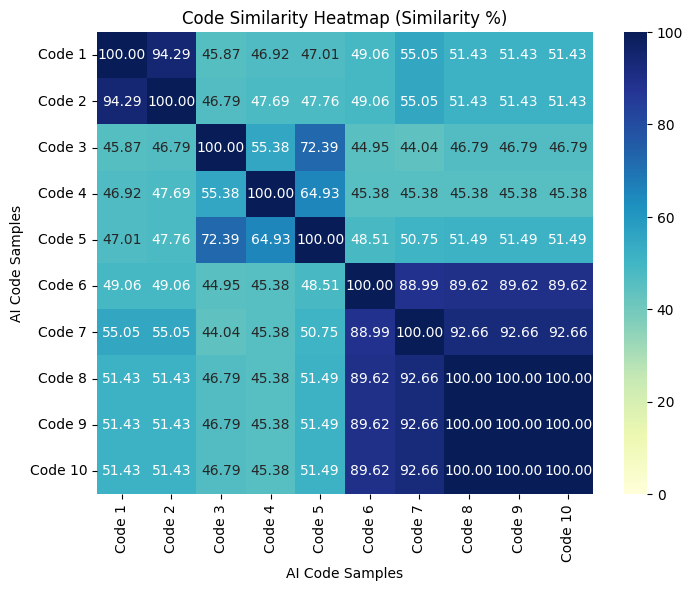

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files3, ai_generated_code=ai_files3, non_plagiarized_code=non_plagiarized_code3, language="java", comparator_class=Comparator, n=15, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()


comparison = MOSS_Fingerprint_Comparison(ai_files3, "java", Comparator2, n=15, window_size=10)
comparison.run()

comparison = MOSS_Fingerprint_Comparison(ai_files3, "java", Comparator3, n=15, window_size=10)
comparison.run()

#### Prompt from case 04
Prompt: Write a program that shows a conversion table from miles to kilometres where one mile is equivalent to 1.609 kilometres. The table should display the first ten positive numbers as miles and pair them with their respective kilometre representation.

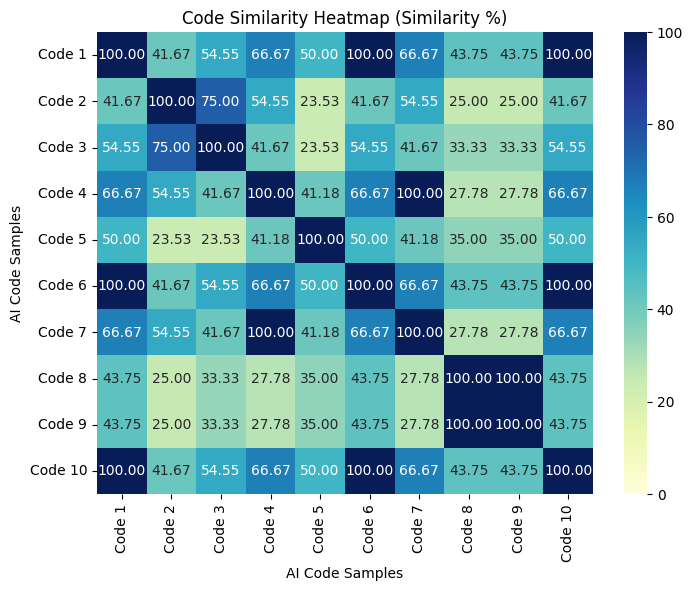

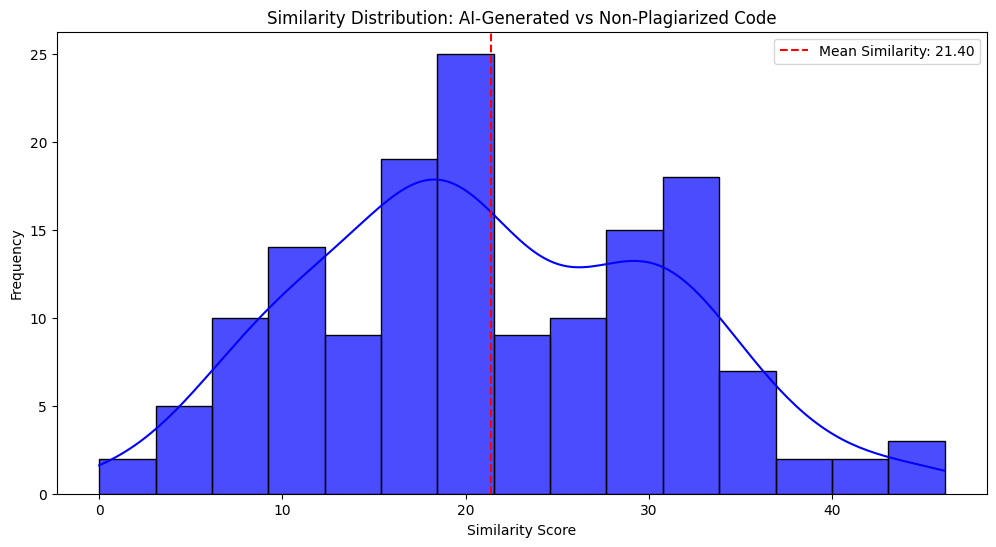

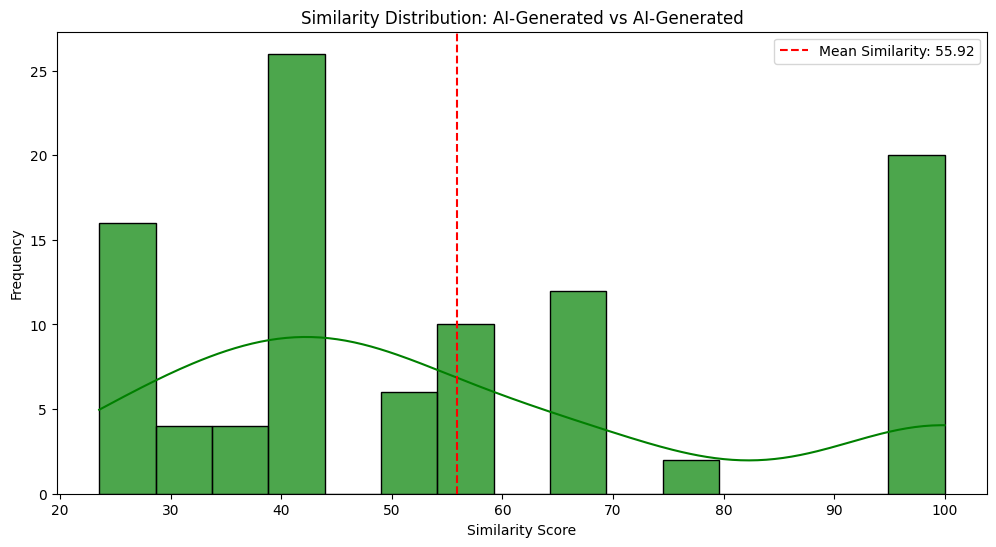

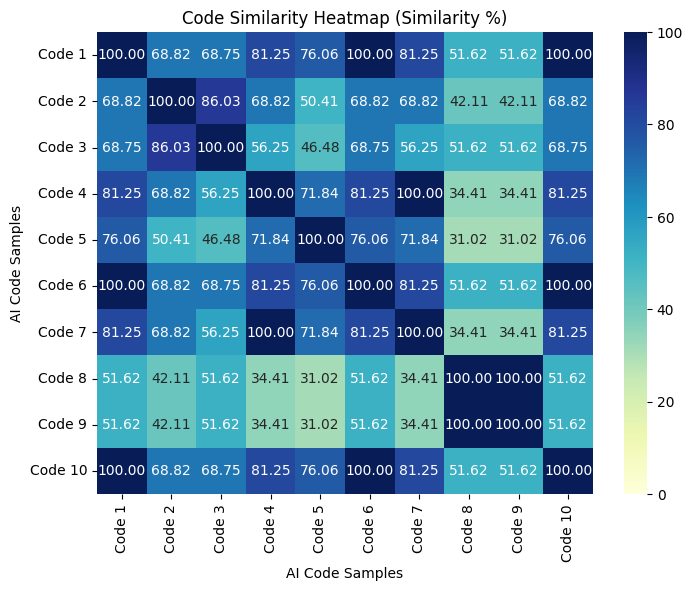

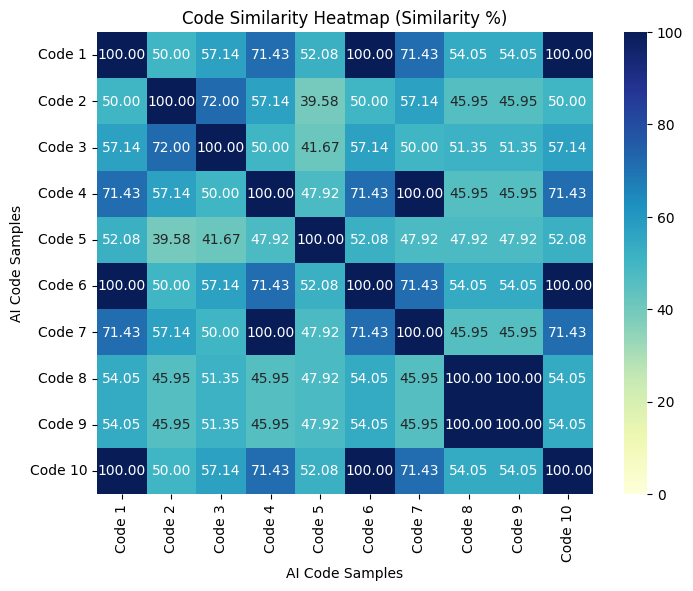

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files4, ai_generated_code=ai_files4, non_plagiarized_code=non_plagiarized_code4, language="java", comparator_class=Comparator, n=15, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

comparison = MOSS_Fingerprint_Comparison(ai_files4, "java", Comparator2, n=15, window_size=10)
comparison.run()

comparison = MOSS_Fingerprint_Comparison(ai_files4, "java", Comparator3, n=15, window_size=10)
comparison.run()

#### Prompt from case 05
Prompt: Write a program that accepts an integer and displays that integer with its digits shown in reverse. You should create and use a method void reverse(int number) which will show the reversed-digit form of the parameterised number.

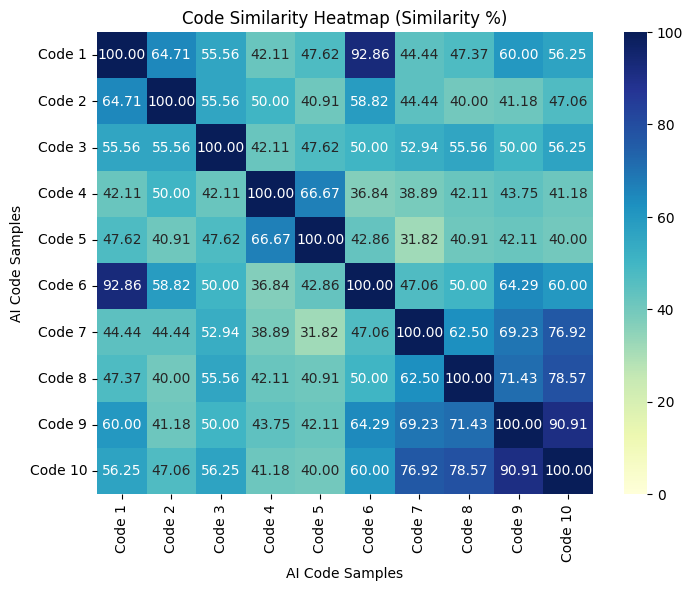

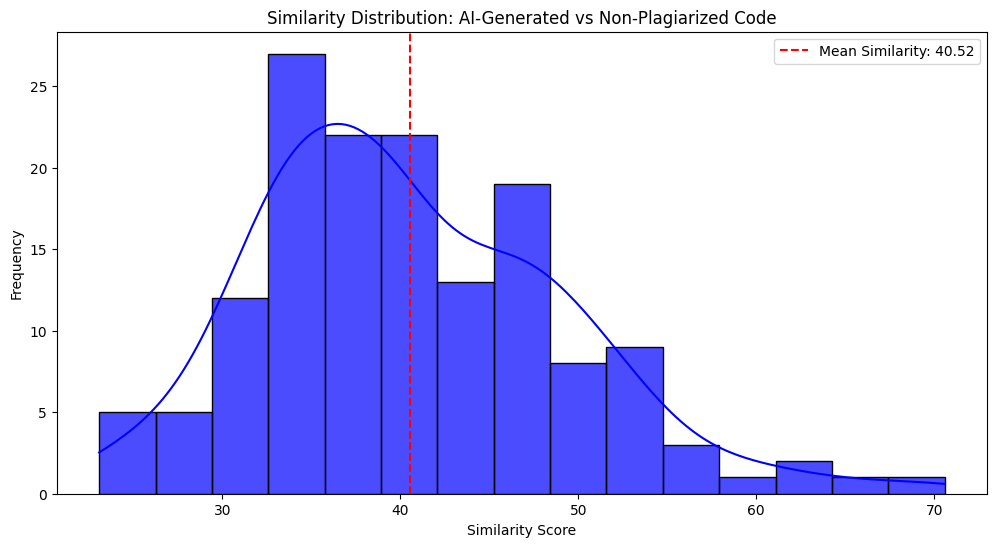

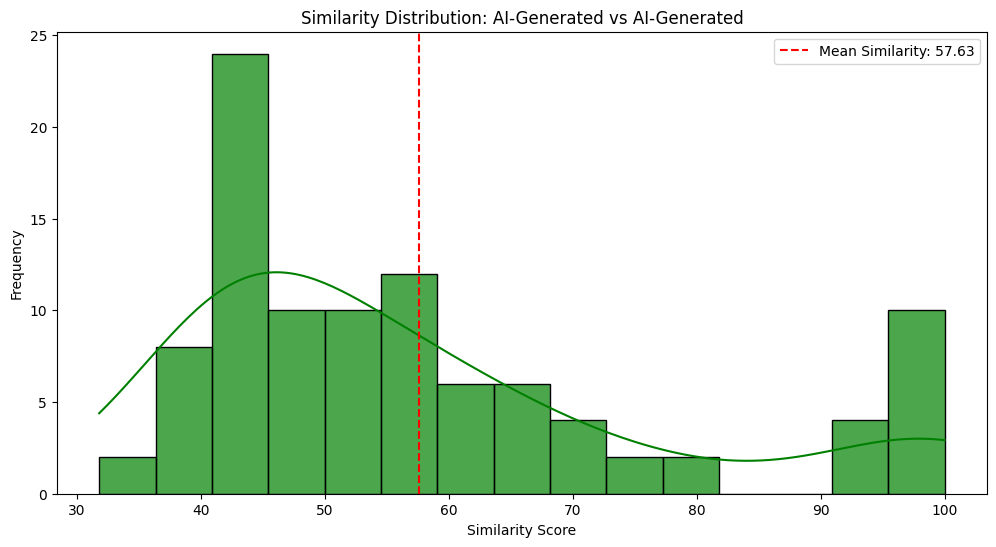

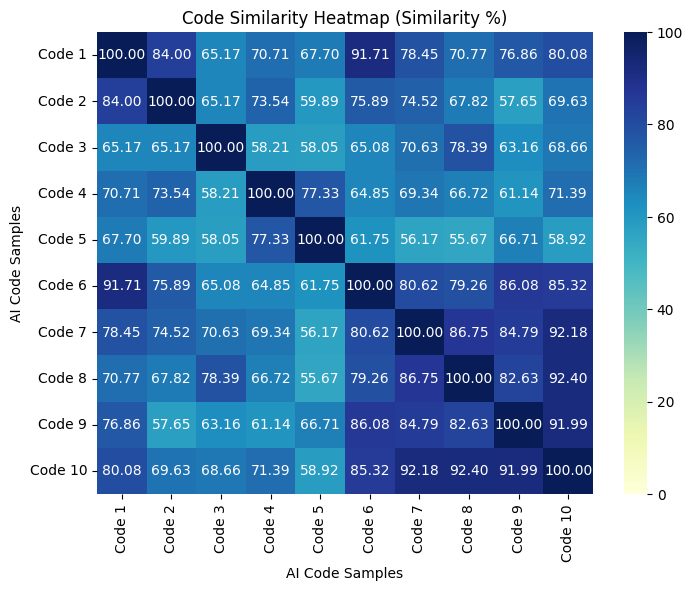

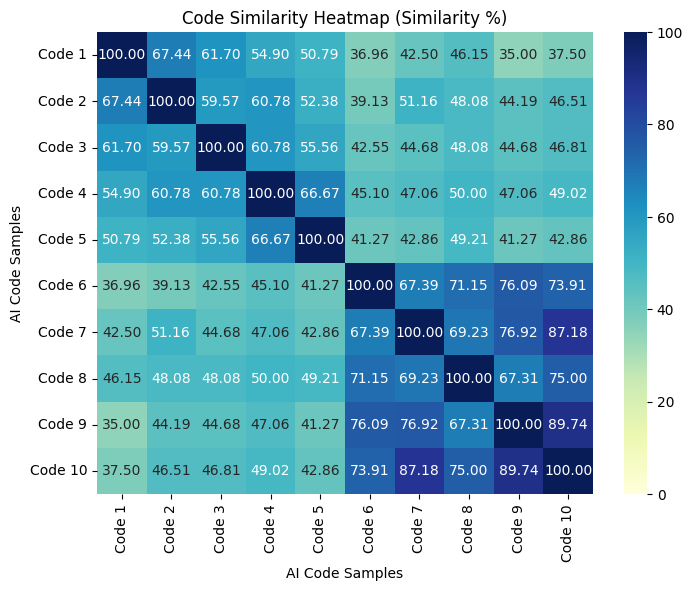

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files5, ai_generated_code=ai_files5, non_plagiarized_code=non_plagiarized_code5, language="java", comparator_class=Comparator, n=15, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

comparison = MOSS_Fingerprint_Comparison(ai_files5, "java", Comparator2, n=15, window_size=10)
comparison.run()

comparison = MOSS_Fingerprint_Comparison(ai_files5, "java", Comparator3, n=15, window_size=10)
comparison.run()

#### Prompt from case 06
Prompt: Write a program that accepts 10 integers and shows them in reversed order.

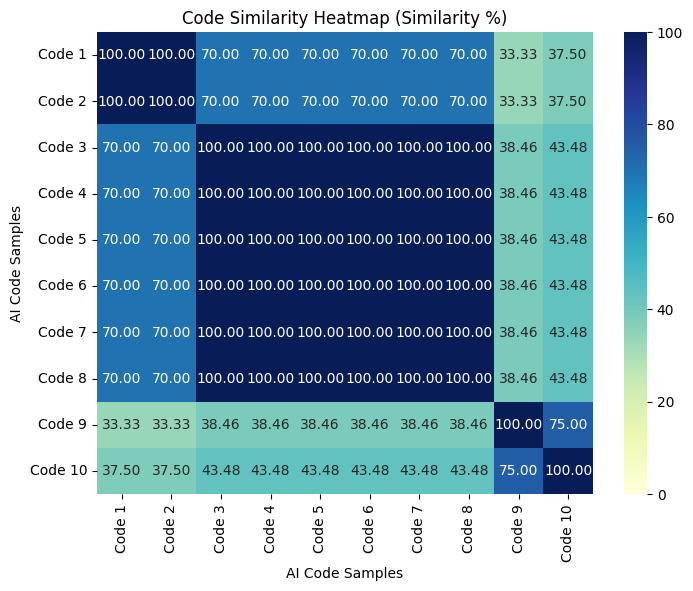

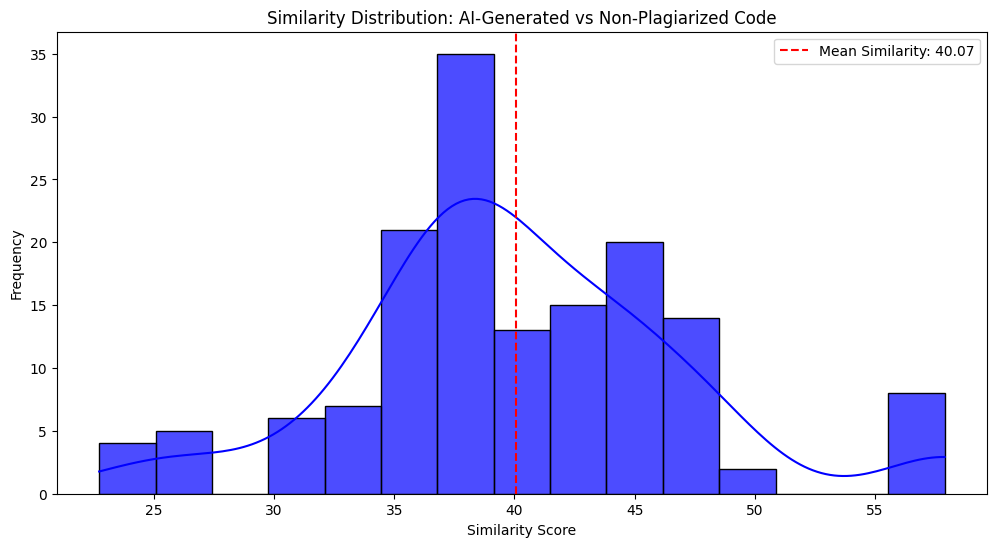

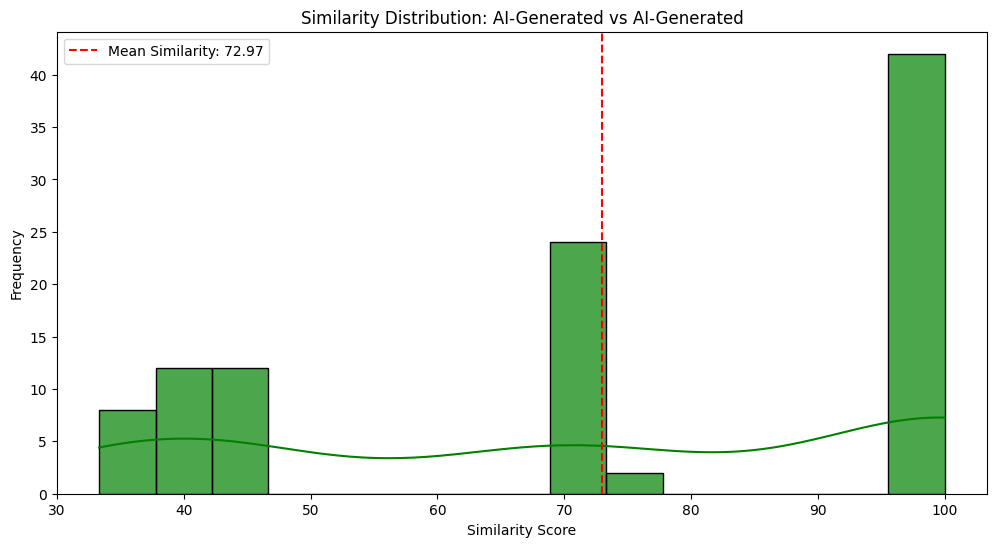

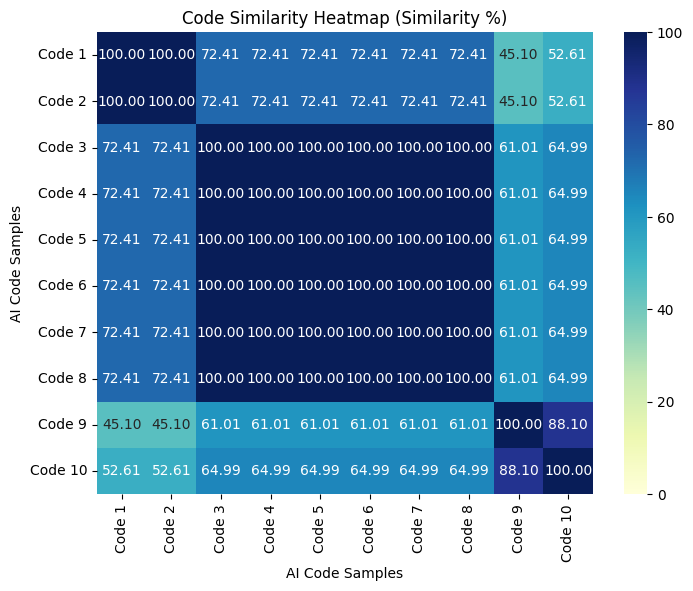

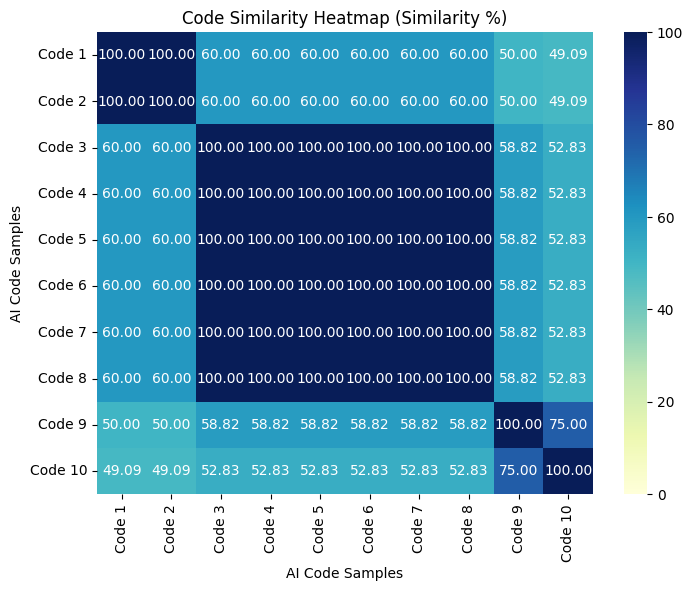

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files6, ai_generated_code=ai_files6, non_plagiarized_code=non_plagiarized_code6, language="java", comparator_class=Comparator, n=15, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

comparison = MOSS_Fingerprint_Comparison(ai_files6, "java", Comparator2, n=15, window_size=10)
comparison.run()

comparison = MOSS_Fingerprint_Comparison(ai_files6, "java", Comparator3, n=15, window_size=10)
comparison.run()

#### Prompt from case 07
Prompt: Write a program that accepts a 4*4 matrix of real numbers and prints the total of all numbers placed on the leading diagonal of the matrix. You should create and use a method double sumMajorDiagonal( double[][] m) which will return the total of all numbers placed on the leading diagonal of the parameterised matrix.

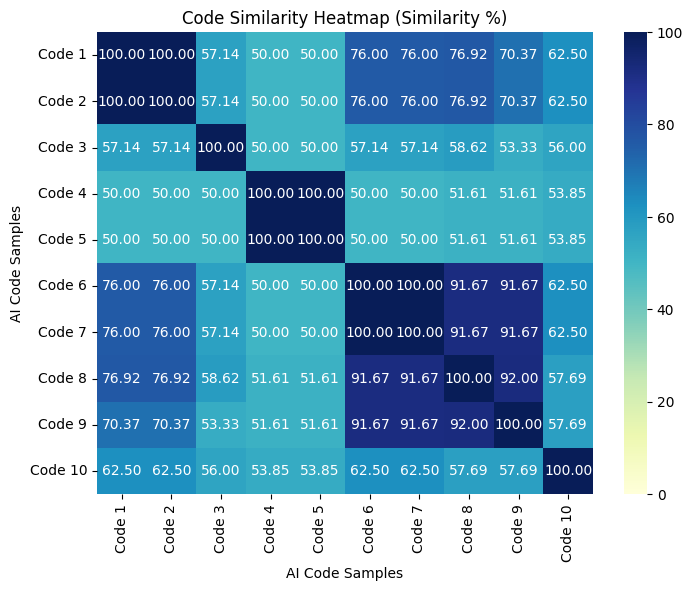

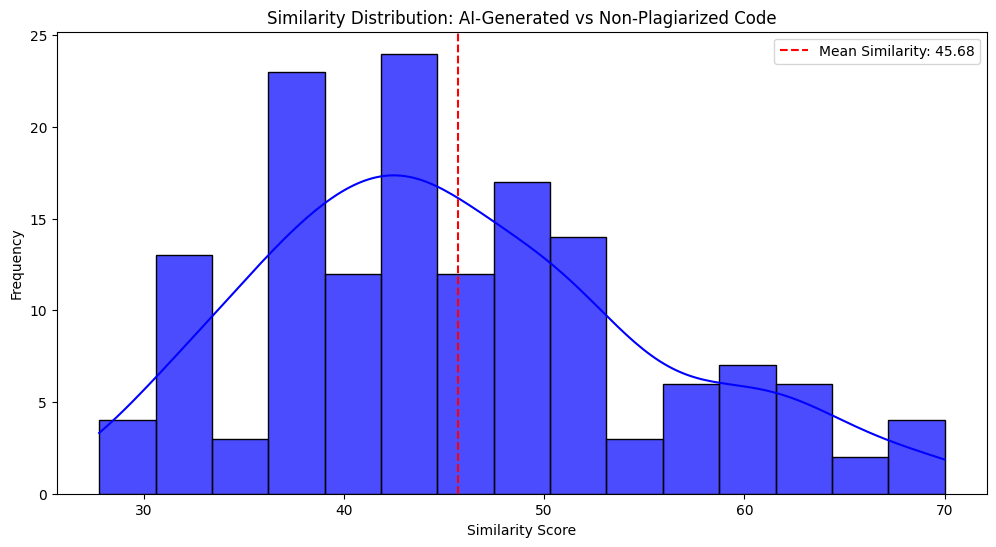

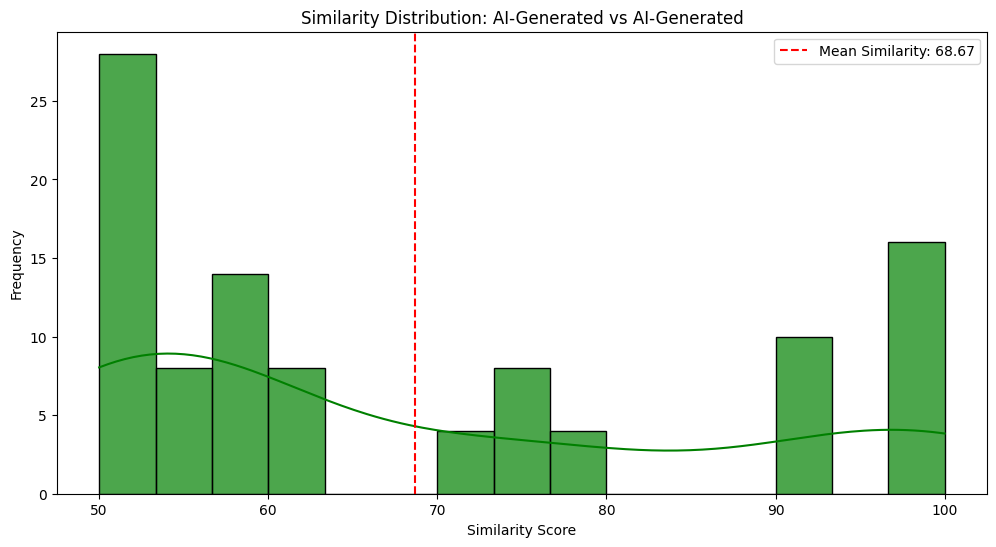

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files7, ai_generated_code=ai_files7, non_plagiarized_code=non_plagiarized_code7, language="java", comparator_class=Comparator, n=15, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

# comparison = MOSS_Fingerprint_Comparison(ai_files7, "java", Comparator3, n=15, window_size=10)
# comparison.run()

# comparison = MOSS_Fingerprint_Comparison(ai_files7, "java", Comparator2, n=15, window_size=10)
# comparison.run()

### Adaptations test:
Preliminary test: check AI genearated code simimlarity with itself
Test: check similarity of AI generated code with non-plagiarised code samples
Using Adaptations Ai-generated code samples

In [ ]:
#EXTRACT DATA FOR NAIVE TESTS FIRST

directory_path1 = './drive/My Drive/FYP/AI_Generated_code/case_01/Adaptations'
directory_path2 = './drive/My Drive/FYP/AI_Generated_code/case_02/Adaptations'
directory_path3 = './drive/My Drive/FYP/AI_Generated_code/case_03/Adaptations'
directory_path4 = './drive/My Drive/FYP/AI_Generated_code/case_04/Adaptations'
directory_path5 = './drive/My Drive/FYP/AI_Generated_code/case_05/Adaptations'
directory_path6 = './drive/My Drive/FYP/AI_Generated_code/case_06/Adaptations'
directory_path7 = './drive/My Drive/FYP/AI_Generated_code/case_07/Adaptations'


def read_files_from_directory(directory_path, file_extension = '.java'):
    """
    Function to read files from a given directory path
    """
    # Dictionary to store file names as keys and file contents as values
    java_files_dict = {}
    file_data = []
    for filename in os.listdir(directory_path):
        if filename.endswith('.java'):
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read()
                java_files_dict[filename] = content
                file_data.append(content)
    return java_files_dict, file_data

dictionary_1 , ai_files1= read_files_from_directory(directory_path1)
dictionary_2 , ai_files2= read_files_from_directory(directory_path2)
dictionary_3 , ai_files3= read_files_from_directory(directory_path3)
dictionary_4 , ai_files4= read_files_from_directory(directory_path4)
dictionary_5 , ai_files5= read_files_from_directory(directory_path5)
dictionary_6 , ai_files6= read_files_from_directory(directory_path6)
dictionary_7 , ai_files7= read_files_from_directory(directory_path7)



#### Prompt 1:

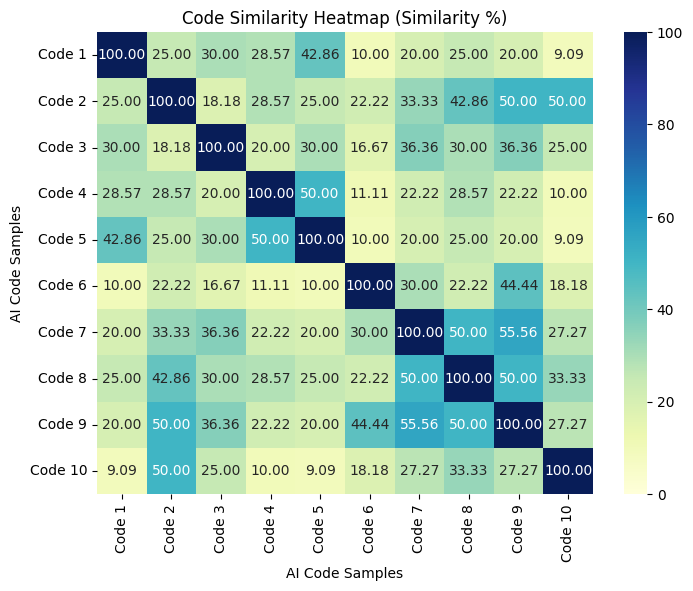

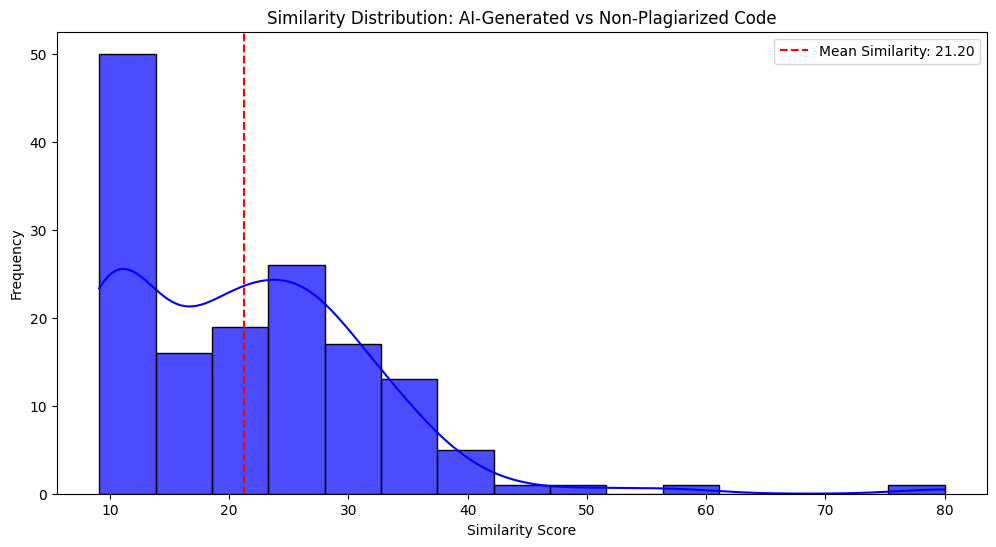

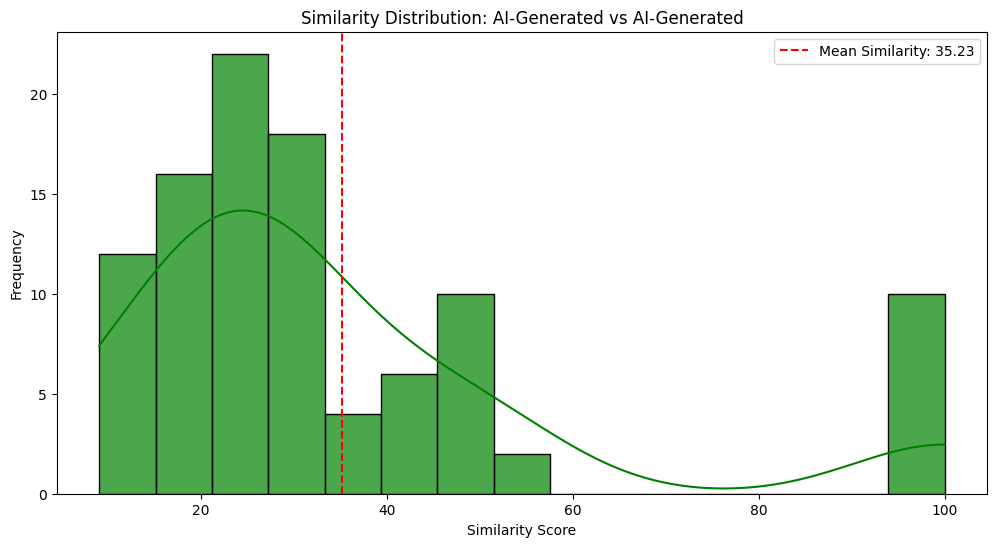

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files1, ai_generated_code=ai_files1, non_plagiarized_code=non_plagiarized_code1, language="java", comparator_class=Comparator, n=5, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

# comparison = MOSS_Fingerprint_Comparison(ai_files1, "java", Comparator3, n=5, window_size=10)
# comparison.run()

# comparison = MOSS_Fingerprint_Comparison(ai_files1, "java", Comparator2, n=5, window_size=10)
# comparison.run()

#### Prompt 2:

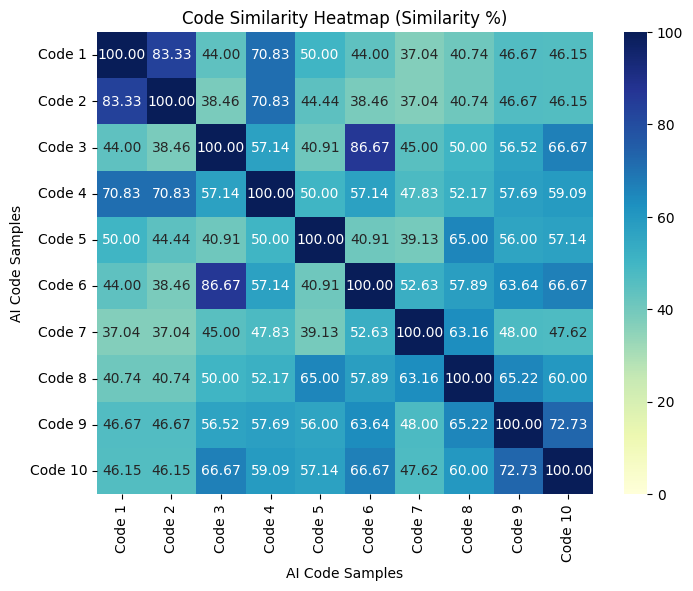

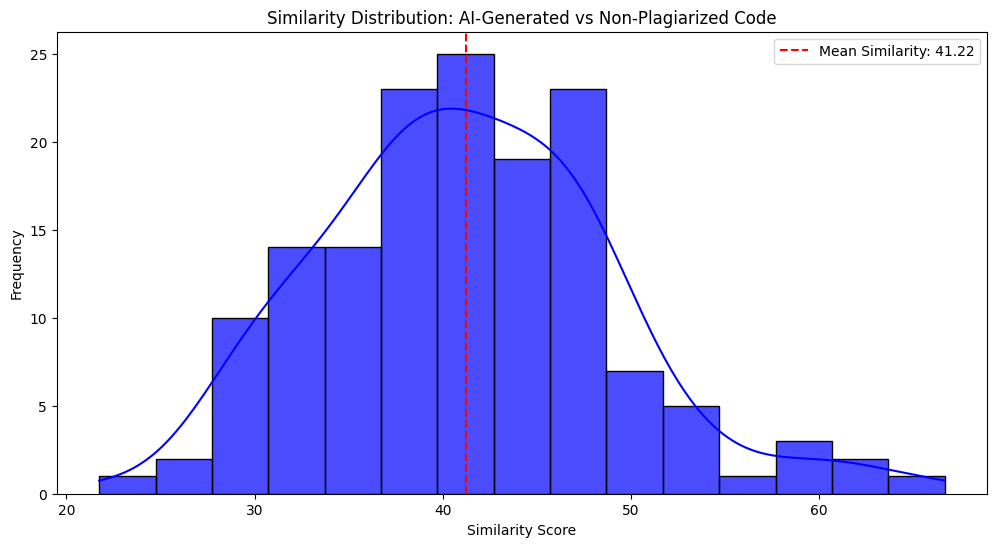

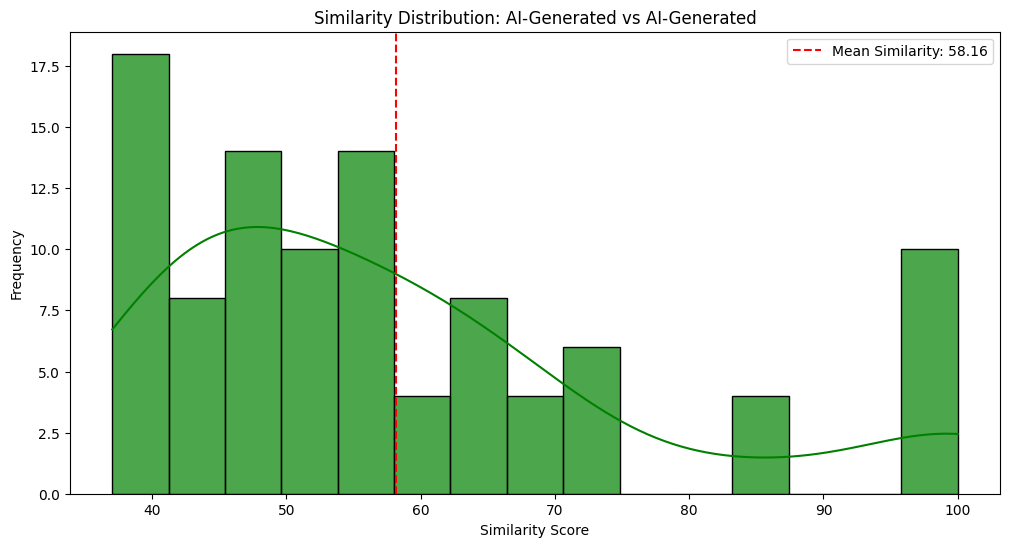

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files2, ai_generated_code=ai_files2, non_plagiarized_code=non_plagiarized_code2, language="java", comparator_class=Comparator, n=5, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

# comparison = MOSS_Fingerprint_Comparison(ai_files2, "java", Comparator3, n=5, window_size=10)
# comparison.run()

# comparison = MOSS_Fingerprint_Comparison(ai_files2, "java", Comparator2, n=5, window_size=10)
# comparison.run()

#### Prompt 3:

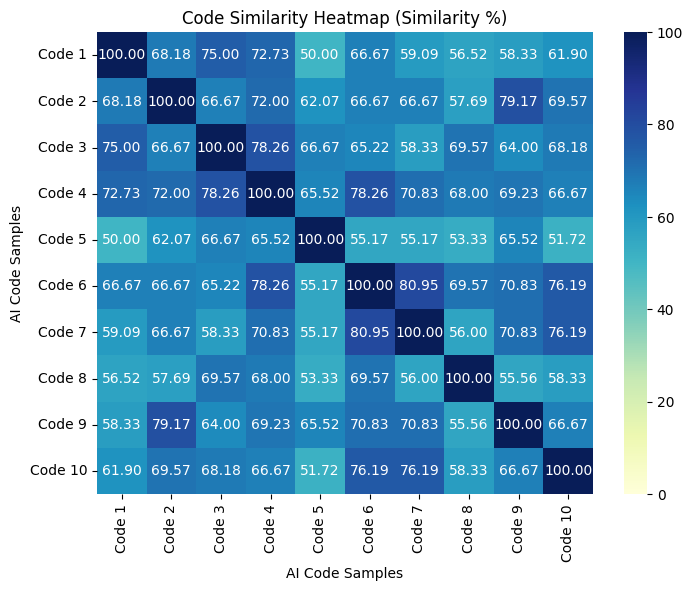

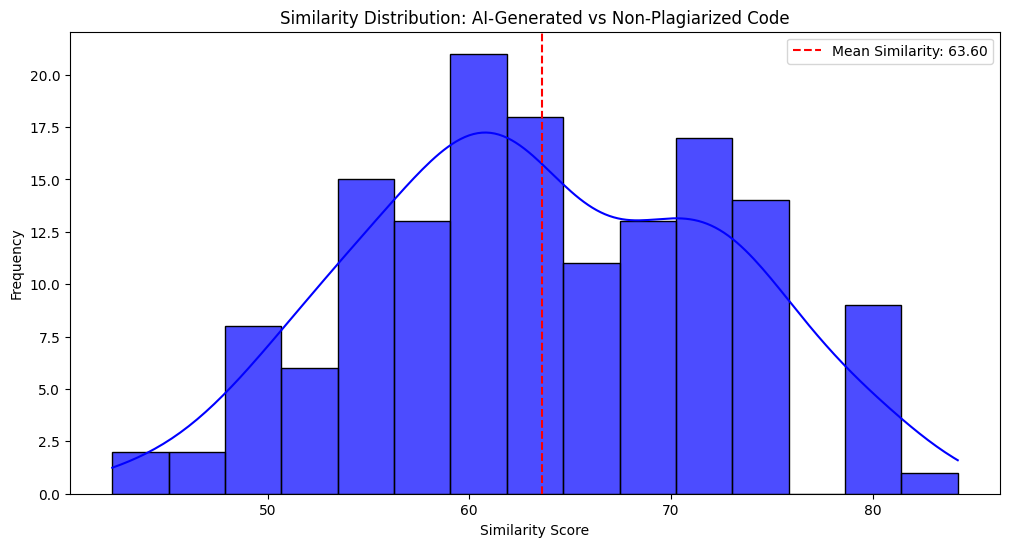

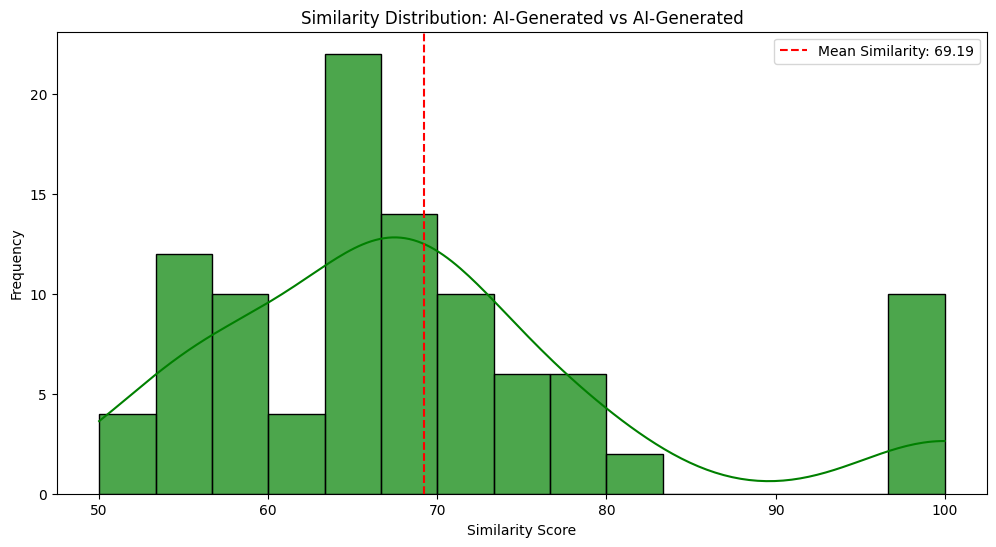

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files3, ai_generated_code=ai_files3, non_plagiarized_code=non_plagiarized_code3, language="java", comparator_class=Comparator, n=5, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

# comparison = MOSS_Fingerprint_Comparison(ai_files3, "java", Comparator3, n=15, window_size=10)
# comparison.run()

# comparison = MOSS_Fingerprint_Comparison(ai_files3, "java", Comparator2, n=15, window_size=10)
# comparison.run()

#### Prompt 4:

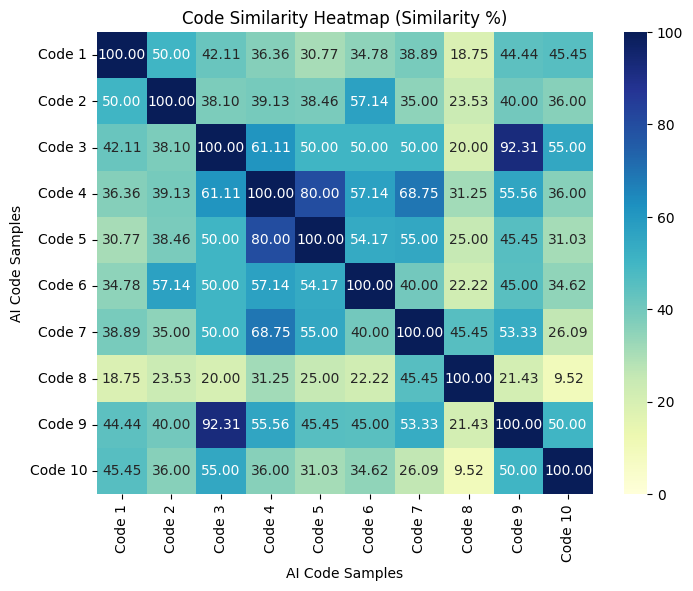

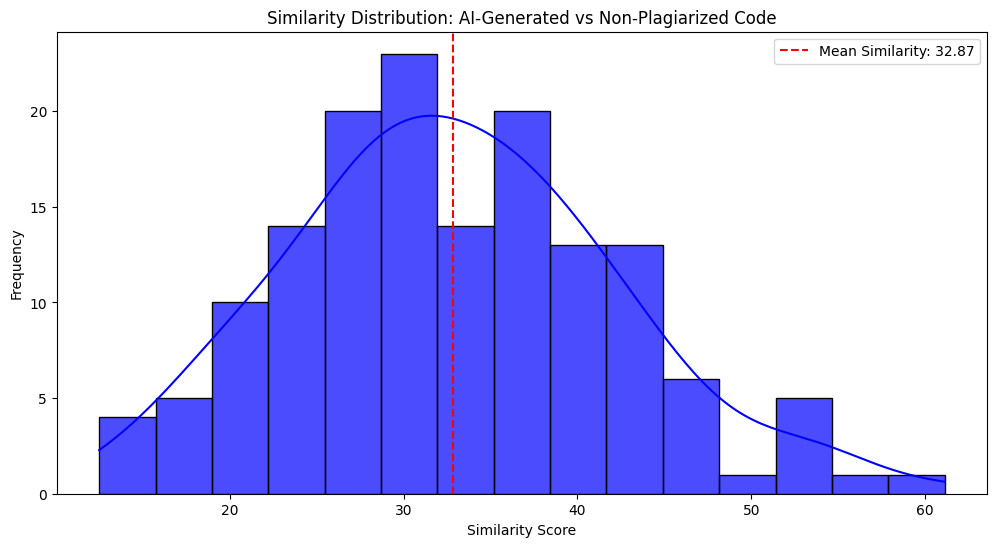

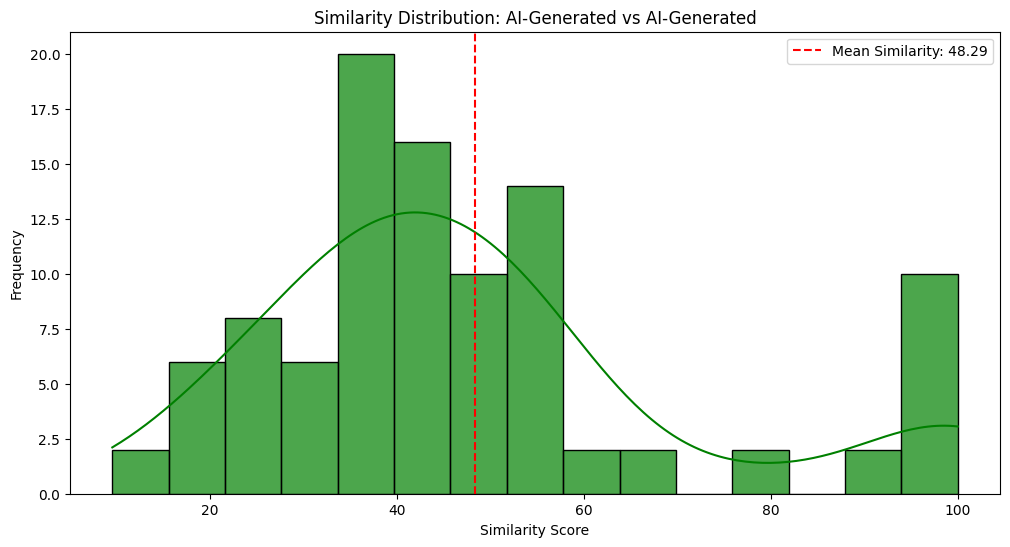

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files4, ai_generated_code=ai_files4, non_plagiarized_code=non_plagiarized_code4, language="java", comparator_class=Comparator, n=5, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

# comparison = MOSS_Fingerprint_Comparison(ai_files4, "java", Comparator3, n=15, window_size=10)
# comparison.run()

# comparison = MOSS_Fingerprint_Comparison(ai_files4, "java", Comparator2, n=15, window_size=10)
# comparison.run()

#### Prompt 5:

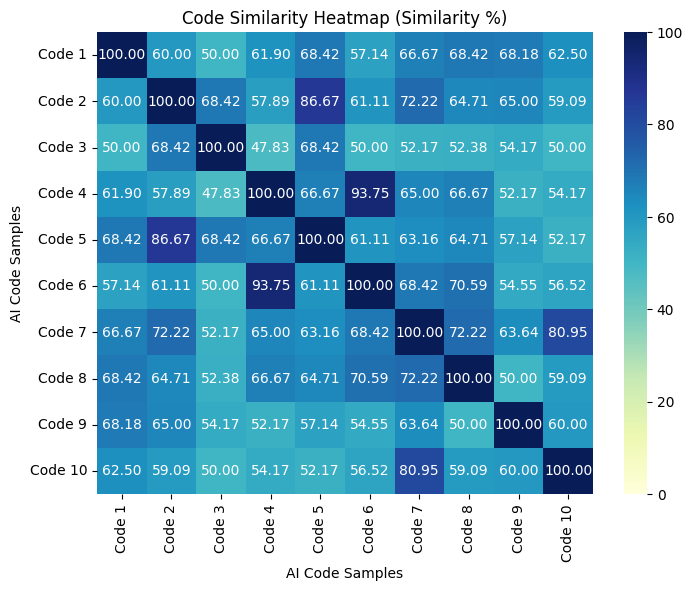

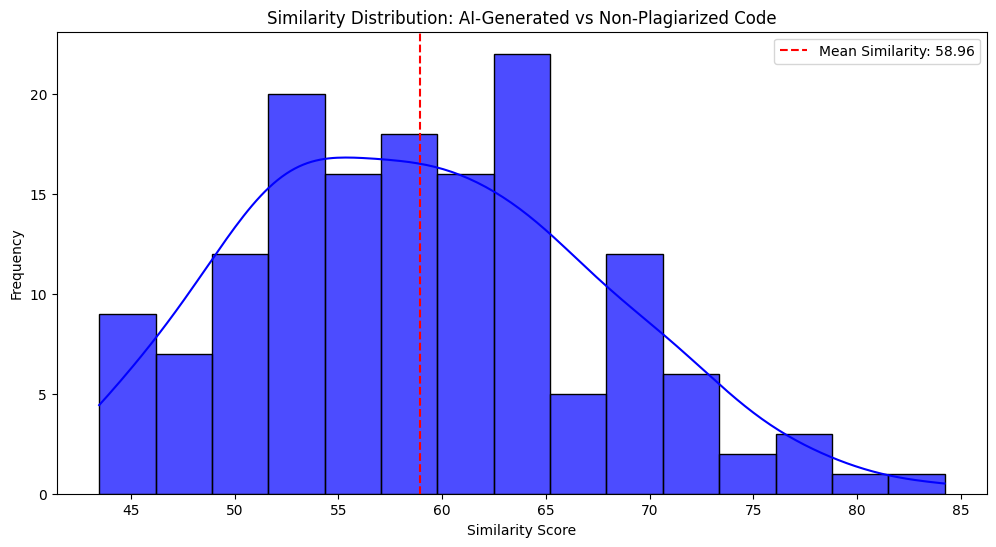

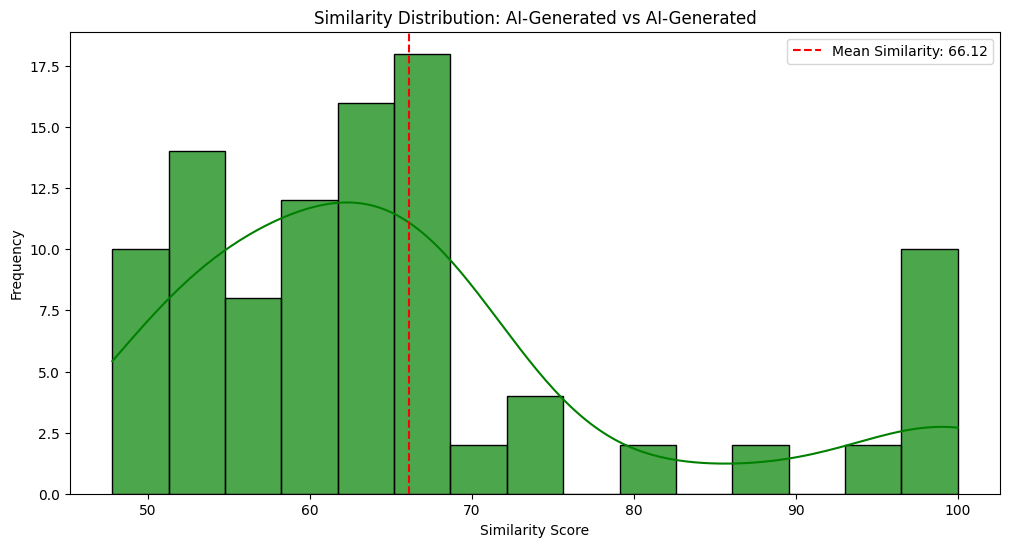

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files5, ai_generated_code=ai_files5, non_plagiarized_code=non_plagiarized_code5, language="java", comparator_class=Comparator, n=5, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

# comparison = MOSS_Fingerprint_Comparison(ai_files5, "java", Comparator3, n=15, window_size=10)
# comparison.run()

# comparison = MOSS_Fingerprint_Comparison(ai_files5, "java", Comparator2, n=15, window_size=10)
# comparison.run()

#### Prompt 6:

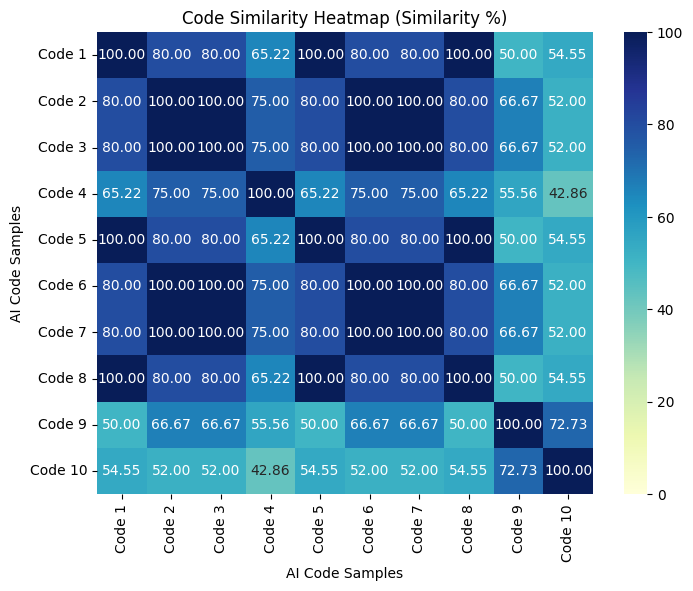

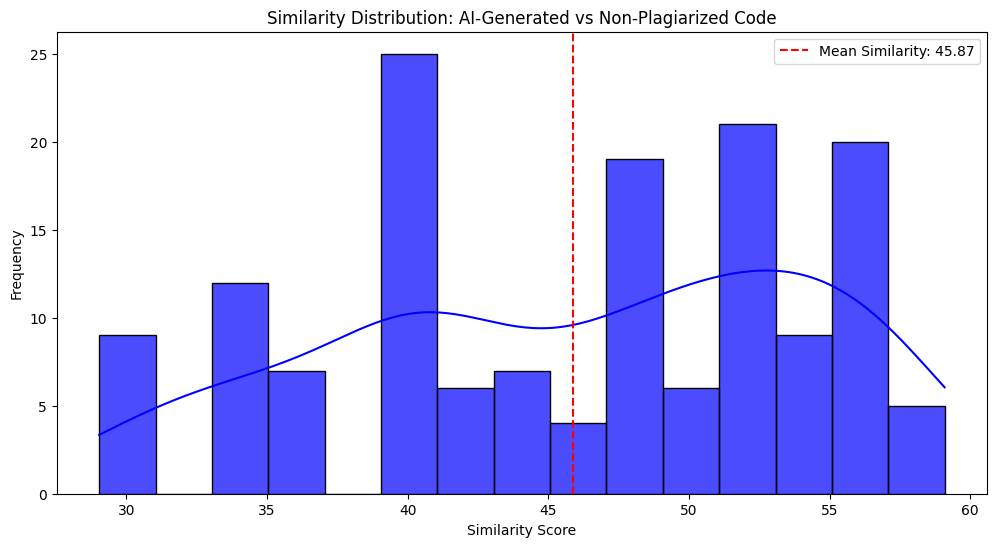

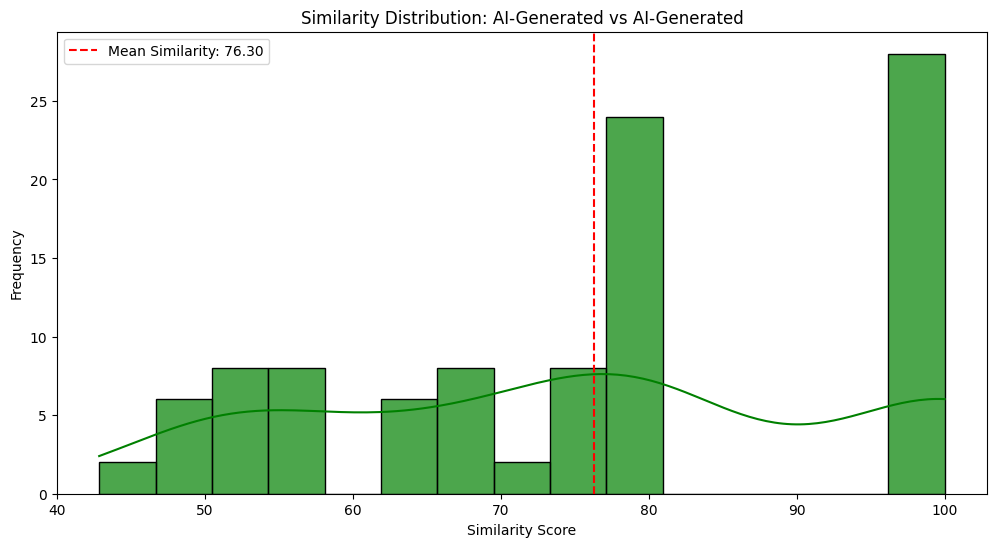

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files6, ai_generated_code=ai_files6, non_plagiarized_code=non_plagiarized_code6, language="java", comparator_class=Comparator, n=5, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

# comparison = MOSS_Fingerprint_Comparison(ai_files6, "java", Comparator3, n=15, window_size=10)
# comparison.run()

# comparison = MOSS_Fingerprint_Comparison(ai_files6, "java", Comparator2, n=15, window_size=10)
# comparison.run()

#### Prompt 7:

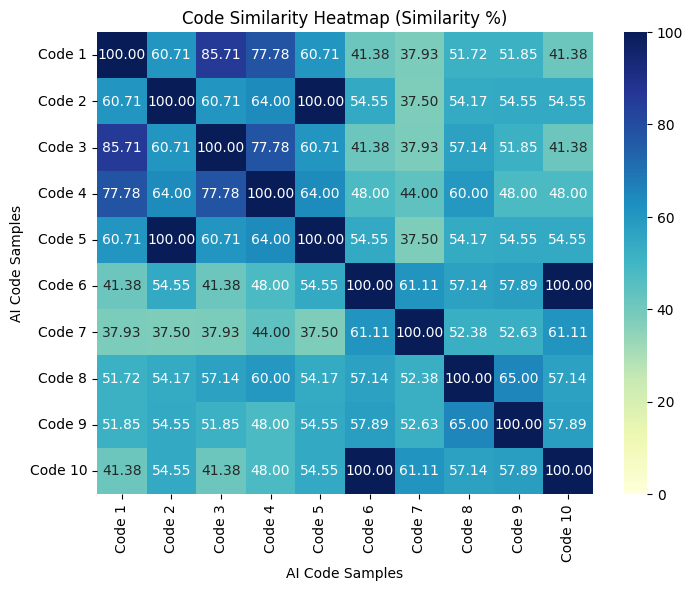

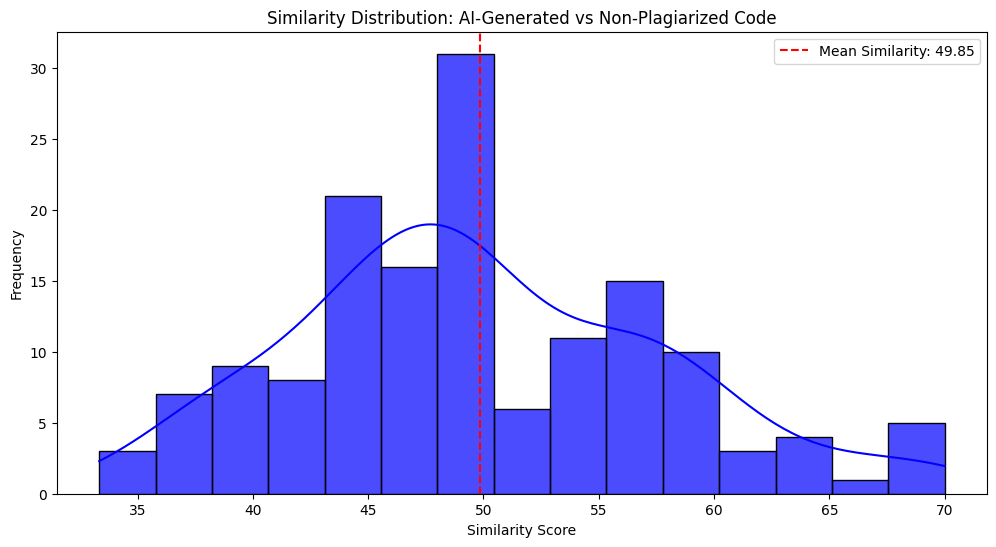

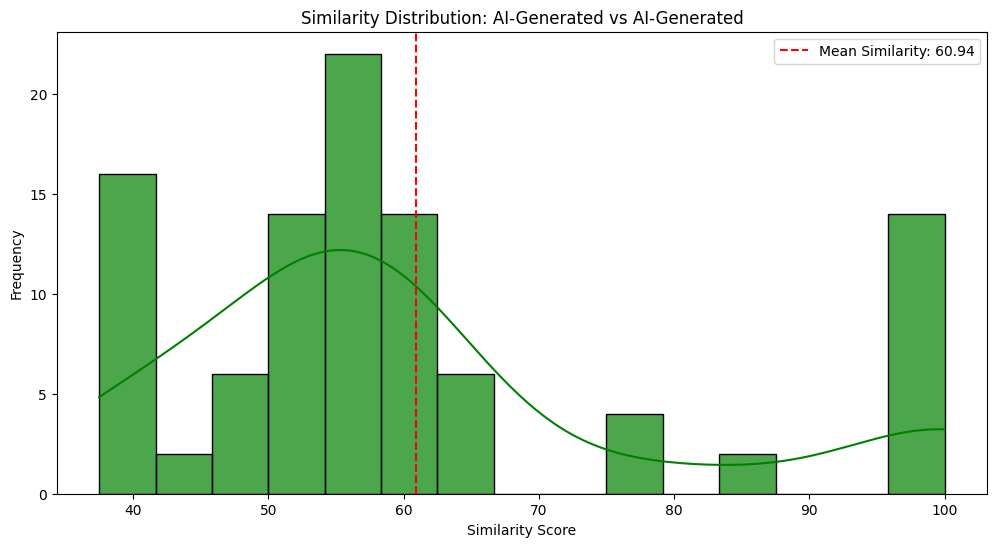

In [ ]:
#CHECK SELF SIMILARITY USING HEATMAP
comparison = MOSS_Fingerprint_Comparison(code_samples=ai_files7, ai_generated_code=ai_files7, non_plagiarized_code=non_plagiarized_code7, language="java", comparator_class=Comparator, n=5, window_size=10)
comparison.run()
comparison.run_ai_vs_non_plag_comparison()
comparison.run_ai_vs_ai_comparison()

# comparison = MOSS_Fingerprint_Comparison(ai_files7, "java", Comparator3, n=15, window_size=10)
# comparison.run()

# comparison = MOSS_Fingerprint_Comparison(ai_files7, "java", Comparator2, n=15, window_size=10)
# comparison.run()

### Different AI models simlarity test

In [ ]:
base_directory = "./drive/My Drive/FYP/AI_Generated_code/case_02"

file_contents = {
    'deepseek': [],
    'claude': [],
    'chatgpt':[]
}


def read_files_from_directory(directory_path, file_extension = '.java'):
    """
    Function to read files from a given directory path
    """
    file_data = []
    for filename in os.listdir(directory_path):
        if filename.endswith('.java'):
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read()
                file_data.append(content)
    return file_data

#read files from each category in the base directory
for category in file_contents.keys():
    directory_path = os.path.join(base_directory, category)
    print(directory_path)
    file_contents[category] = read_files_from_directory(directory_path)

chatgpt = file_contents['chatgpt']
deepseek = file_contents['deepseek']
claude = file_contents['claude']

./drive/My Drive/FYP/AI_Generated_code/case_02/deepseek
./drive/My Drive/FYP/AI_Generated_code/case_02/claude
./drive/My Drive/FYP/AI_Generated_code/case_02/chatgpt


In [ ]:
class MOSS_Fingerprint_Comparison_AI_Models:
    def __init__(self, chatgpt_code, deepseek_code, claude_code, language, comparator_class, n=20, window_size=10):
        self.chatgpt_code = chatgpt_code
        self.deepseek_code = deepseek_code
        self.claude_code = claude_code
        self.language = language
        self.comparator_class = comparator_class
        self.n = n
        self.window_size = window_size
        self.moss_chatgpt_instances = []
        self.moss_deepseek_instances = []
        self.moss_claude_instances = []
        self.similarity_matrix_deepseek = None  # Similarity matrix for ChatGPT vs DeepSeek
        self.similarity_matrix_claude = None    # Similarity matrix for ChatGPT vs Claude

    def generate_fingerprints(self):
        """Generates fingerprints for ChatGPT, DeepSeek, and Claude code samples."""
        for code in self.chatgpt_code:
            moss = MOSS(code, self.language, n=self.n, window_size=self.window_size)
            moss.run()
            self.moss_chatgpt_instances.append(moss)

        for code in self.deepseek_code:
            moss = MOSS(code, self.language, n=self.n, window_size=self.window_size)
            moss.run()
            self.moss_deepseek_instances.append(moss)

        for code in self.claude_code:
            moss = MOSS(code, self.language, n=self.n, window_size=self.window_size)
            moss.run()
            self.moss_claude_instances.append(moss)

    def compute_similarity_matrix(self, target_instances):
        """Computes similarity matrix between ChatGPT and target instances (DeepSeek or Claude)."""
        num_chatgpt = len(self.moss_chatgpt_instances)
        num_target = len(target_instances)

        similarity_matrix = np.zeros((num_chatgpt, num_target))

        for i, moss_chatgpt in enumerate(self.moss_chatgpt_instances):
            for j, moss_target in enumerate(target_instances):
                comparator = self.comparator_class(moss_instance_1=moss_chatgpt, moss_instance_2=moss_target)
                similarity_matrix[i, j] = comparator.compare()

        return similarity_matrix

    def compare_chatgpt_vs_deepseek(self):
        """Computes similarity matrix for ChatGPT vs DeepSeek."""
        self.similarity_matrix_deepseek = self.compute_similarity_matrix(self.moss_deepseek_instances)

    def compare_chatgpt_vs_claude(self):
        """Computes similarity matrix for ChatGPT vs Claude."""
        self.similarity_matrix_claude = self.compute_similarity_matrix(self.moss_claude_instances)

    def plot_heatmap(self, similarity_matrix, title, x_labels, y_labels):
        """Plots a heatmap for the given similarity matrix."""
        plt.figure(figsize=(10, 6))
        sns.heatmap(similarity_matrix, annot=True, cmap="YlGnBu", fmt=".2f", xticklabels=x_labels, yticklabels=y_labels)
        plt.title(title)
        plt.xlabel("Target Code Samples")
        plt.ylabel("ChatGPT Code Samples")
        plt.show()

    def plot_heatmap_chatgpt_vs_deepseek(self):
        """Plots heatmap for ChatGPT vs DeepSeek."""
        if self.similarity_matrix_deepseek is not None:
            x_labels = [f"DeepSeek {i+1}" for i in range(len(self.deepseek_code))]
            y_labels = [f"ChatGPT {i+1}" for i in range(len(self.chatgpt_code))]
            self.plot_heatmap(self.similarity_matrix_deepseek, "ChatGPT vs DeepSeek Similarity", x_labels, y_labels)

    def plot_heatmap_chatgpt_vs_claude(self):
        """Plots heatmap for ChatGPT vs Claude."""
        if self.similarity_matrix_claude is not None:
            x_labels = [f"Claude {i+1}" for i in range(len(self.claude_code))]
            y_labels = [f"ChatGPT {i+1}" for i in range(len(self.chatgpt_code))]
            self.plot_heatmap(self.similarity_matrix_claude, "ChatGPT vs Claude Similarity", x_labels, y_labels)

    def run_chatgpt_vs_others(self):
        """Runs full fingerprinting and comparison for ChatGPT vs DeepSeek & Claude."""
        self.generate_fingerprints()
        self.compare_chatgpt_vs_deepseek()
        self.compare_chatgpt_vs_claude()
        self.plot_heatmap_chatgpt_vs_deepseek()
        self.plot_heatmap_chatgpt_vs_claude()


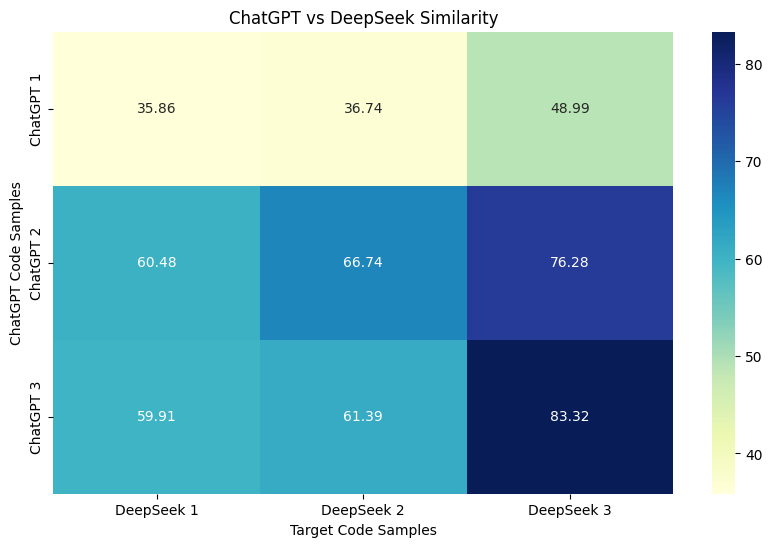

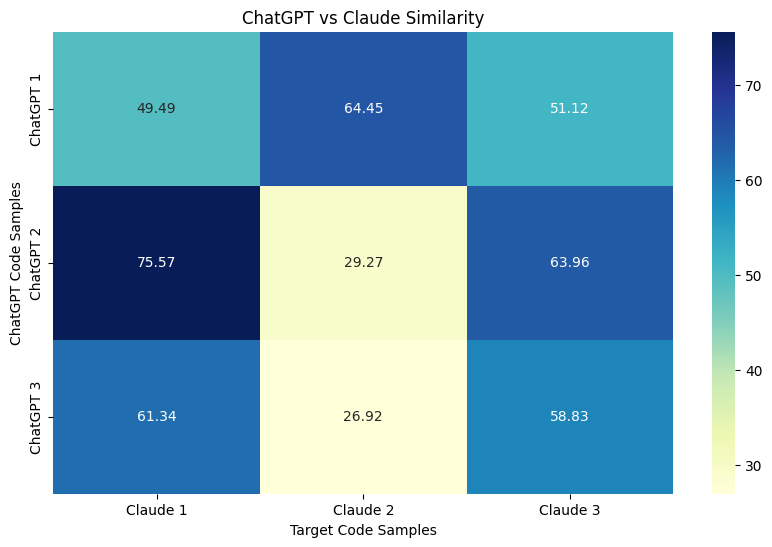

In [ ]:
comparison = MOSS_Fingerprint_Comparison_AI_Models(
    chatgpt_code=chatgpt,
    deepseek_code=deepseek,
    claude_code=claude,
    language="java",
    comparator_class=Comparator2
)

comparison.run_chatgpt_vs_others()


This highlights the strikingly high similarity between solutions generated by different AI models, with many of them having over 60% similarity the highest being 86%

In [ ]:
print(chatgpt[1]) #chatgpt2

import java.util.Scanner;

public class CylinderAreaVolumeCalculator {
    public static void main(String[] args) {
        Scanner scanner = new Scanner(System.in);

        // Prompt user for radius and length of the cylinder
        System.out.print("Enter the radius of the cylinder: ");
        double radius = scanner.nextDouble();

        System.out.print("Enter the length of the cylinder: ");
        double length = scanner.nextDouble();

        // Calculate area and volume
        double area = radius * radius * 3.14159;
        double volume = area * length;

        // Output the results
        System.out.printf("The area of the cylinder is: %.4f\n", area);
        System.out.printf("The volume of the cylinder is: %.4f\n", volume);

        scanner.close();
    }
}



In [ ]:
print(claude[1]) #claude2

import java.util.Scanner;

public class CylinderCalculator {
    public static void main(String[] args) {
        // Create Scanner object for input
        Scanner scanner = new Scanner(System.in);
        
        // Define PI constant
        final double PI = 3.14159;
        
        // Prompt and get radius input
        System.out.println("Enter the radius of the cylinder:");
        double radius = scanner.nextDouble();
        
        // Prompt and get length input
        System.out.println("Enter the length of the cylinder:");
        double length = scanner.nextDouble();
        
        // Calculate the circle area (base of cylinder)
        double area = radius * radius * PI;
        
        // Calculate the volume of the cylinder
        double volume = area * length;
        
        // Output the results
        System.out.println("The area of the cylinder is: " + area);
        System.out.println("The volume of the cylinder is: " + volume);
        
        // Close

In [ ]:
#create MOSS objects
moss1 = MOSS(chatgpt[1], "java")
moss2 = MOSS(claude[1], "java")

#run the MOSS algorithm
moss1.run()
moss2.run()

In [ ]:
#compare the two
comparator = Comparator2(moss1, moss2)
similarity_score = comparator.compare()
print("Similarity Score: " + str(similarity_score)+"%")

Similarity Score: 29.839754672317763%


This highlights an interesting observation and a deficiency of the algorithm, though to the trained human eye the above two code files have high similarity, the MOSS algorithm classifies them as only having ~29% similarity. This is because algorthm focues on syntactic similaritites only and may be 'tricked' even by small structural changes even though the logic is almost identical.

In [ ]:
code1 = """import java.util.Scanner;

public class ReverseIntegers {

    public static void main(String[] args) {
        // Create a scanner object to take user input
        Scanner scanner = new Scanner(System.in);

        // Create an array to store the integers
        int[] numbers = new int[10];

        // Prompt the user to enter 10 integers
        System.out.println("Enter 10 integers:");

        // Read 10 integers from the user
        for (int i = 0; i < 10; i++) {
            System.out.print("Enter integer " + (i + 1) + ": ");
            numbers[i] = scanner.nextInt();
        }

        // Show the integers in reversed order
        System.out.println("\nIntegers in reversed order:");
        for (int i = 9; i >= 0; i--) {
            System.out.print(numbers[i] + " ");
        }

        // Close the scanner to avoid resource leaks
        scanner.close();
    }
}"""

code2 = """import java.util.Scanner;

public class ReverseIntegers {

    public static void main(String[] args) {
        // Create a scanner object to take user input
        Scanner scanner = new Scanner(System.in);

        // Create an array to store the integers
        int[] numbers = new int[10];

        // Prompt the user to enter 10 integers
        System.out.println("Enter 10 integers:");

        // Read 10 integers from the user using a while loop
        int i = 0;
        while (i < 10) {
            System.out.print("Enter integer " + (i + 1) + ": ");
            numbers[i] = scanner.nextInt();
            i++; // Increment counter
        }

        // Show the integers in reversed order using a while loop
        System.out.println("\nIntegers in reversed order:");
        int j = 9;
        while (j >= 0) {
            System.out.print(numbers[j] + " ");
            j--; // Decrement counter
        }

        // Close the scanner to avoid resource leaks
        scanner.close();
    }
}
"""

In [ ]:
#create MOSS objects
moss1 = MOSS(code1, "java")
moss2 = MOSS(code2, "java")

#run the MOSS algorithm
moss1.run()
moss2.run()

In [ ]:
#compare the two
comparator = Comparator(moss1, moss2)
similarity_score = comparator.compare()
print("Similarity Score: " + str(similarity_score)+"%")

Similarity Score: 48.93617021276596%


This is another example of two code samples generated by an AI model with almost identical logic(simply changed a 'for loop' with a 'while loop'), to the human eye this is clearly 'plagiarized' and yet the similarity score is only around 50% (still a high score but these sample are almost identical, the only difference is the loop structure)

In [ ]:
code1 = """import java.util.Scanner;

public class ReverseDigits {

    public static void main(String[] args) {
        Scanner scanner = new Scanner(System.in);

        // Prompt the user to enter an integer
        System.out.println("Enter an integer: ");
        int number = scanner.nextInt();

        // Call the reverse method to display the reversed number
        reverse(number);

        scanner.close();
    }

    // Method to reverse the digits of the given integer
    public static void reverse(int number) {
        // While loop to reverse the number
        while (number != 0) {
            // Print the last digit
            System.out.println(number % 10);

            // Remove the last digit from the number
            number /= 10;
        }

    }
}
"""

code2 = """import java.util.Scanner;

public class ReverseDigits {

    public static void main(String[] args) {
        // Create a scanner object to take user input
        Scanner scanner = new Scanner(System.in);

        // Prompt the user to enter an integer
        System.out.print("Enter an integer: ");
        int number = scanner.nextInt();

        // Reverse the number directly within main
        System.out.print("Reversed number: ");

        while (number != 0) {
            System.out.print(number % 10);  // Print the last digit
            number /= 10;  // Remove last digit
        }

        System.out.println();  // New line for formatting

        // Close the scanner
        scanner.close();
    }
}
"""

In [ ]:
#create MOSS objects
moss1 = MOSS(code1, "java")
moss2 = MOSS(code2, "java")

#run the MOSS algorithm
moss1.run()
moss2.run()

In [ ]:
#compare the two
comparator = Comparator(moss1, moss2)
similarity_score = comparator.compare()
print("Similarity Score: " + str(similarity_score)+"%")

Similarity Score: 51.61290322580645%


This is another example of two code samples generated by an AI model with almost identical logic(just some structural differences), to the human eye this is clearly 'plagiarized' and yet the similarity score is only around 50% (still a high score but these sample are almost identical, the only difference the use or absence of methods)

In [ ]:
class MOSS_Fingerprint_Comparison_Cluster:
  def __init__(self, code_samples, language, comparator_class, n=20, window_size=10):
        self.code_samples = code_samples  # List of code samples
        self.language = language
        self.comparator_class = comparator_class
        self.n = n  # K-gram size
        self.window_size = window_size  # Window size for winnowing
        self.moss_instances = []  # Store MOSS instances for each sample
        self.similarity_matrix = None
        self.similarity_scores = []

  def generate_fingerprints(self):
        """Generates fingerprints for each code sample using the MOSS class"""
        for code in self.code_samples:
            moss = MOSS(code, self.language, n=self.n, window_size=self.window_size)
            moss.run()  # Run the full MOSS pipeline for each code sample
            self.moss_instances.append(moss)

  def compute_similarity_matrix(self):
      """Computes the similarity matrix using the Comparator class"""
      num_samples = len(self.moss_instances)
      self.similarity_matrix = np.zeros((num_samples, num_samples))

      for i in range(num_samples):
          for j in range(num_samples):
              if i != j:
                  comparator = self.comparator_class(moss_instance_1=self.moss_instances[i], moss_instance_2=self.moss_instances[j])
                  similarity_score = comparator.compare()
                  self.similarity_matrix[i, j] = similarity_score
              else:
                  self.similarity_matrix[i, j] = 100  # Self-similarity is 100%

  def plot_heatmap(self):
      """Visualizes the similarity matrix using a heatmap"""
      plt.figure(figsize=(8, 6))
      sns.heatmap(
          self.similarity_matrix,
          cmap="YlGnBu",
          fmt=".2f",
          xticklabels=[f"Code {i+1}" for i in range(len(self.code_samples))],
          yticklabels=[f"Code {i+1}" for i in range(len(self.code_samples))],
          vmin=0, vmax=100
      )
      plt.title("Code Similarity Heatmap (Similarity %)")
      plt.xlabel("AI Code Samples")
      plt.ylabel("AI Code Samples")
      plt.show()

  def run(self):
      """Run all steps for comparison and visualisation"""
      self.generate_fingerprints()
      self.compute_similarity_matrix()
      self.plot_heatmap()


In [ ]:
directory_path = "./drive/My Drive/FYP/AI_Generated_code/clusters"

def read_files_from_directory(directory_path, file_extension = '.java'):
    """
    Function to read files from a given directory path
    """
    file_data = []
    for filename in os.listdir(directory_path):
        if filename.endswith('.java'):
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read()
                file_data.append(content)
    return file_data

#read files from each category in the base directory
clusters = read_files_from_directory(directory_path)



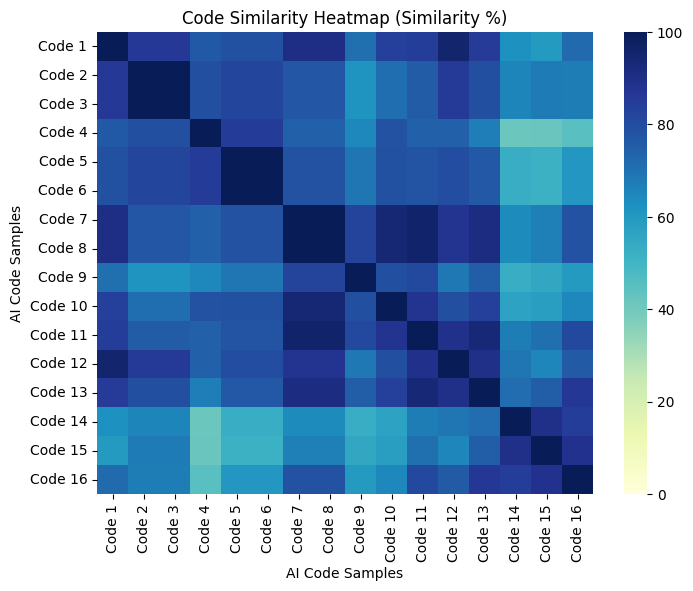

In [ ]:
comparison = MOSS_Fingerprint_Comparison_Cluster(clusters, "java", Comparator2, n=15, window_size=10)
comparison.run()

This shows to 'clustering' of AI-generated code, when generated 'naively', when an extremely large amount of the same task is generated directly with no modifications added the code outputs have high similarity. (this was generates using task 7)